# DESAFIO IC — VOXAR LABS 2026
## Classificação de Superfícies de Vias por Imagem

---
**Autor:** Arthur Gabriel Silva da Luz  
**Data:** 30/04/2026  
**Contato:** [agsl@cin.ufpe.br](mailto:agsl@cin.ufpe.br)

---

## Índice (Não funciona direito no colab, mas funciona no vscode)

1. [Identificação e Justificativa da Abordagem](#1)
2. [Configurações Globais e Reprodutibilidade](#2)
3. [EDA — Análise Exploratória de Dados](#3)
4. [Pré-processamento e Pipeline de Transformações](#4)
5. [Experimento 1 — Baseline ResNet-18 (sem correção de desbalanceamento)](#5)
6. [Função de Treinamento e Métricas](#6)
7. [Experimento 2 — ResNet-50 com Weighted Loss](#7)
8. [Experimento 3 — ResNet-50 com Data Augmentation Agressivo](#8)
9. [Experimento 4 — EfficientNet-B0 com Data Augmentation e Weighted Loss](#9)
10. [Análise de Interpretabilidade com Grad-CAM](#10)
11. [Sumário Comparativo dos Experimentos](#11)
12. [Teste de robustez com múltiplas seeds](#12)
13. [Conclusão final e o que poderia ser feito com mais tempo:](#13)


In [1]:
!pip install opencv-python
!pip install grad-cam

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import cv2 # Para analisar o brilho/contraste das imagens q nem escrito no pdf da Voxar
from PIL import Image
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights, efficientnet_b0, EfficientNet_B0_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from tqdm import tqdm # Barra de progresso para verificar o treinamento

from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              balanced_accuracy_score, f1_score,
                              average_precision_score)


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


# Registro do ambiente treinado.

In [82]:
# Registro do Ambiente
import sys
import pkg_resources

print(f"Python       : {sys.version}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.version.cuda}")
print(f"cuDNN        : {torch.backends.cudnn.version()}")

libs = ['torchvision', 'sklearn', 'numpy', 'pandas', 'matplotlib',
        'seaborn', 'PIL', 'cv2', 'grad_cam']
for lib in libs:
    try:
        dist = pkg_resources.get_distribution(lib)
        print(f"{lib:<15}: {dist.version}")
    except Exception:
        try:
            mod = __import__(lib)
            print(f"{lib:<15}: {getattr(mod, '__version__', 'instalado')}")
        except:
            print(f"{lib:<15}: não encontrado")

if torch.cuda.is_available():
    print(f"\nGPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/tmp/ipykernel_3379/1199769856.py:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Python       : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch      : 2.10.0+cu128
CUDA         : 12.8
cuDNN        : 91002
torchvision    : 0.25.0+cu128
sklearn        : 1.6.1
numpy          : 2.0.2
pandas         : 2.2.2
matplotlib     : 3.10.0
seaborn        : 0.13.2
PIL            : 11.3.0
cv2            : 4.13.0
grad_cam       : 1.5.5

GPU          : Tesla T4
VRAM total   : 15.6 GB


<a id='1'></a>
## 1. Identificação da Abordagem

### Natureza do Problema

Classificação supervisionada de imagens em **3 classes de superfície**:

- **Classe 1**: Asphalt        | Asfalto, superfície uniforme
- **Classe 2**: Belgian_blocks | Paralelepípedos ou blocos de granito, facilmente confundido com Asphalt
- **Classe 3**: Offroad        | Superfície não pavimentada(terra, cascalho, areia...), em situações com pouca visibilidade é difícil de classificar

### Desafios Antecipados

- **Desbalanceamento severo**: o pdf enviado explica que o dataset está altamente desbalanceado, logo os modelos terão uma tendência a ignorar classes minoritárias.

- **Variações de captura**: iluminação variável (chuva, noite, sol direto), múltiplos dispositivos de captura e ângulos de câmera.

- **Ambiguidade visual**: asphalt molhado pode assemelhar-se a belgian_blocks; offroad com lama pode parecer asphalt escuro.
- **Overfitting em dataset pequeno (880 imagens de treino e 300 imagens de teste):** Com apenas 880 imagens para treino e 300 para teste, qualquer rede profunda pode memorizar o treino em poucas épocas.  
- **Hipótese**: `Dropout`, `BatchNorm` na camada classificadora e weight decay devem regularizar o modelo.

### Abordagem Escolhida: Transfer Learning(fine-tuning de redes pré-treinadas no ImageNet)

**Razões pela escolha**:

1. **Dataset pequeno**: com 880 amostras de treino, treinar uma rede profunda do zero seria muito trabalhoso e levaria a um possível overfitting. As redes pré-treinadas já possuem filtros que detectam bordas, texturas e padrões de alta frequência, facilitando a distinção das três classes.

2. **Domínio relacionado**: apesar de ImageNet conter imagens de objetos cotidianos (animais, veículos, etc.), os filtros de baixo e médio nível são transferíveis para qualquer tarefa de visão. Padrões de textura de solo, asfalto e pedra são bem capturados pelas camadas iniciais de ResNets.

**Arquiteturas exploradas**:
- `ResNet-18`: baseline rápido e leve (~11M parâmetros) para estabelecer o piso de desempenho.
- `ResNet-50`: backbone mais profundo (~25M parâmetros) para verificar se mais capacidade representacional ajuda. O uso do ResNet50 possivelmente apresentará o melhor resultado com base no seguinte artigo <a href='https://arxiv.org/abs/2010.11929'>An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale</a> que indica que esse modelo dá bons resultados em datasets com poucas imagens.
- `EfficientNet-B0`: arquitetura mais moderna e eficiente (~5.3M parâmetros), com melhor trade-off acurácia/custo computacional.

### Métricas principais e ferramentas de análise:
* **F1-Score por Classe**
* **F1-Score Macro**
* **Matriz de confusão**
* **Balanced Accuracy**

**Ferramenta de interpretabilidade**: **Grad-CAM** — permite verificar se o modelo está "olhando" para as regiões semanticamente relevantes (textura da superfície) ou para artefatos espúrios (iluminação, bordas da câmera).

### Bibliotecas Utilizadas
- **PyTorch**: modelo, treinamento, DataLoader
- **scikit-learn**: métricas (balanced accuracy, F1, report, confusion matrix)
- **matplotlib / seaborn**: visualizações
- **numpy / pandas**: manipulação de dados


### Design Experimental: Isolamento de Variáveis

```
+ ResNet-18, loss uniforme, resize direto 224×224      ->  Exp.1(baseline)
+ ResNet-50 + weighted loss                            ->  Exp.2
+ data augmentation rico + resize correto              ->  Exp.3
+ EfficientNet-B0 + WeightedRandomSampler              ->  Exp.4
```

<a id='2'></a>
# 2. Configurações globais do colab

Todas as fontes de aleatoriedade utilizadas com Python, random, NumPy, PyTorch (CPU e CUDA) — são fixadas com a mesma semente (`42`). Nesse colab, não será feito teste com diferentes seeds, devido uma ausência de tempo maior.


In [ ]:
"""
Útil para carregar os arquivos no google drive

# Baixa o arquivo do Google Drive usando o ID
!gdown --id 1WEk5aC_-iJAsopnERPC5VGAgEFJyq1bQ -O dataset.zip

# Extrai o arquivo zip
!unzip -q dataset.zip -d /content/

# Remove o arquivo zip para liberar espaço na RAM/Disco da máquina virtual
os.remove('dataset.zip')

print("Dataset baixado e extraído com sucesso!")

"""

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WEk5aC_-iJAsopnERPC5VGAgEFJyq1bQ
From (redirected): https://drive.google.com/uc?id=1WEk5aC_-iJAsopnERPC5VGAgEFJyq1bQ&confirm=t&uuid=c445abf6-14e2-4dc7-bc33-eb33c1070bc1
To: /content/dataset.zip
100% 61.8M/61.8M [00:00<00:00, 91.9MB/s]
replace /content/dataset_voxar/test/belgian_blocks/j_ns_bb_15_1_000461.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset baixado e extraído com sucesso!


In [ ]:
config = {
    'data_dir':      './dataset_voxar',
    'batch_size':    32,
    'num_workers':   2,
    'num_epochs':    20,
    'learning_rate': 1e-4,
    'weight_decay':  1e-4,    # Regularização L2 no otimizador
    'patience_lr':   5,       # Épocas sem melhora antes de reduzir LR
    'device':        'cuda' if torch.cuda.is_available() else 'cpu',
    'classes':       ['asphalt', 'belgian_blocks', 'offroad'],
    'seed':          42,
    'multi_seeds':   [42, 7, 2026] # Diferentes seeds para análise de multi-seeds (seção 13)
}
# Não coloquei as epochs aqui, mas para os experimentos 1 e 2 foi 10 epochs e para os experimentos 3 e 4, 15 epochs.

In [85]:
def all_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

all_seeds(config['seed'])

In [86]:
device = torch.device(config['device'])
device

device(type='cuda')

<a id='3'></a>

<h1>3. EDA - Análise Explorativa de Dados 📊</h1>

Nessa seção, será visualizada o número de imagens por classe no split de treino e outros fatores.

Antes de qualquer processo de tratamento e treinamento, é essencial ter noção do quão desbalanceado é o dataset. A ideia é que após a análise explorativa dos dados seja possível responder algumas perguntas como:

1. **Qual o grau de desbalanceamento?** - A resposta dessa pergunta influenciará na distribuição dos pesos na loss function.

2. **Qual a variação de resolução?** - A resposta dessa pergunta me orientará quanto a estratégia de redimensionamento das imagens.

3. **Como é a distribuição do brilho nas imagens?** - Indica se augmentation faz sentido.


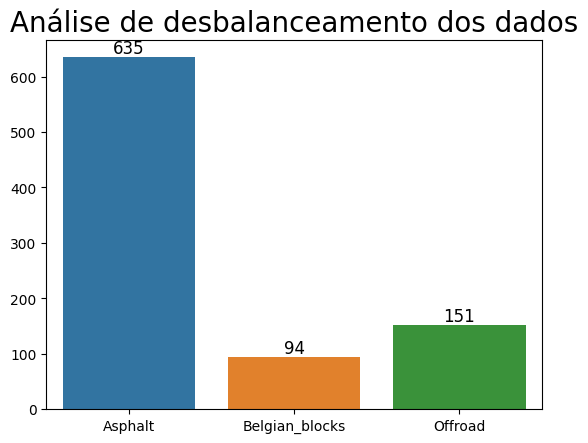

Razão de desbalanceamento: Asphalt/belgian_blocks = 6.8x


In [87]:
quantidade_asphalt = len(os.listdir(config['data_dir']+'/train/asphalt'))
quantidade_belgian = len(os.listdir(config['data_dir']+'/train/belgian_blocks'))
quantidade_offroad = len(os.listdir(config['data_dir']+'/train/offroad'))

train_size = pd.DataFrame.from_dict({
    'Asphalt': [quantidade_asphalt],
    'Belgian_blocks': [quantidade_belgian],
    'Offroad': [quantidade_offroad]
})

grafico_em_barras = sns.barplot(data=train_size)
grafico_em_barras.set_title('Análise de desbalanceamento dos dados', fontsize=20)

for barra in grafico_em_barras.patches:
  altura_barra = barra.get_height()

  grafico_em_barras.annotate(f'{int(altura_barra)}',
                            (barra.get_x()+ barra.get_width()/2, altura_barra),
                            ha='center',
                            va='bottom',
                            fontsize=12,)

plt.show()

print(f"Razão de desbalanceamento: Asphalt/belgian_blocks = {quantidade_asphalt/quantidade_belgian:.1f}x")

`Leitura Rápida`

Existem 635 imagens da classe Asphalt, 94 imagens com a classe belgian_blocks e 151 imagens com a classe offroad. Logo, `asphalt` coresponde a 72,15% das amostras de treino, enquanto `belgian_blocks` corresponde a 10,68%. A consequência direta é que a acurácia é uma métrica **TOTALMENTE ENGANOSA** nesse caso. Uma vez que um classificador que somente preveja a classe `asphalt` acertará 72% das vezes, sem aprender nada sobre as imagens. Portanto, a métrica f1-score e f1-macro serão bastante importante.

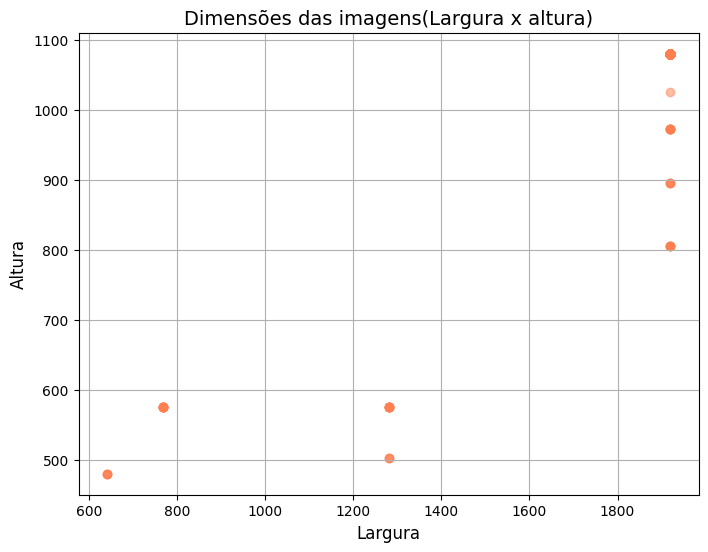


-------------------------------------------------------
 Informações das dimensões das imagens:

Largura mínima: 640 px
Largura máxima: 1920 px

Altura mínima: 480px
Altura máxima: 1080px

Média de largura: 1798 px
Média de altura: 995 px
-------------------------------------------------------


In [88]:
"""
Essa função tem como objetivo analisar as dimensões das imagens.
As imagens costumam ter diferentes tipos de resolução, podendo ir geralmente de 1920x1080
a 16x16. Se as imagens forem muito grandes, dimensioná-las para 224x224 através de um ReSize,
as imagens podem ficar um pouco distorcidas, impactando negativamente na performance do modelo.
"""
def analyze_images(data_dir, quantidade_amostras=200):
  classes = ['asphalt', 'belgian_blocks', 'offroad']
  path = data_dir+'/train'

  all_images = []

  for classe in classes:
    path_class = path + '/' + classe
    name_archives = os.listdir(path_class) # Listar todos os arqiuvos

    for name_arc in name_archives:
      all_images.append(path_class + '/' + name_arc)

  random.shuffle(all_images) # Embaralhar as imagens de acordo com a seed lá do início
  samples_img = all_images[:quantidade_amostras] # Pega as 100 primeiras imagens dentro da ordem aleatória do random.shuffle

  widths = []  # largura
  heights = [] # altura

  for name_img in samples_img:
    img = Image.open(name_img)
    width_img, height_img = img.size

    widths.append(width_img) # Descobrir os pixels/dimensão da imagem, planejo fazer um resize, caso necessário.
    heights.append(height_img)

  # Criação do gráfico a partir dos dados
  plt.figure(figsize=(8,6))
  plt.scatter(widths, heights, color='coral', alpha=0.5) # alpha=0.5 é pra deixar meio transparente meio opaco
  plt.title('Dimensões das imagens(Largura x altura)', fontsize=14)
  plt.xlabel('Largura', fontsize=12)
  plt.ylabel('Altura', fontsize=12)
  plt.grid(True)
  plt.show()

  print()
  print('-'*55)
  print(' Informações das dimensões das imagens:')
  print()
  print(f'Largura mínima: {min(widths)} px')
  print(f'Largura máxima: {max(widths)} px')

  print(f'\nAltura mínima: {min(heights)}px')
  print(f'Altura máxima: {max(heights)}px')

  print(f'\nMédia de largura: {np.mean(widths):.0f} px')
  print(f'Média de altura: {np.mean(heights):.0f} px')
  print('-' * 55)


analyze_images(config['data_dir'])



`Leitura Rápida`

A maioria das imagens está próxima de 1920x1080. Redimensionar para 224x224 indicaria diminuir a escala da imagem em 8,5x, o que pode deixar muito difícil para o modelo detectar os paralelepípedos nos belgian_blocks e erroneamente indicando Asphalt como resposta. Portanto, a estratégia utilizada será: `Resize(256) + Centercrop(224)`. O Resize redimensiona a imagem para 256 px, enquanto o CenterCrop(224) recorta o centro, eliminando as bordas que contém menos informação.

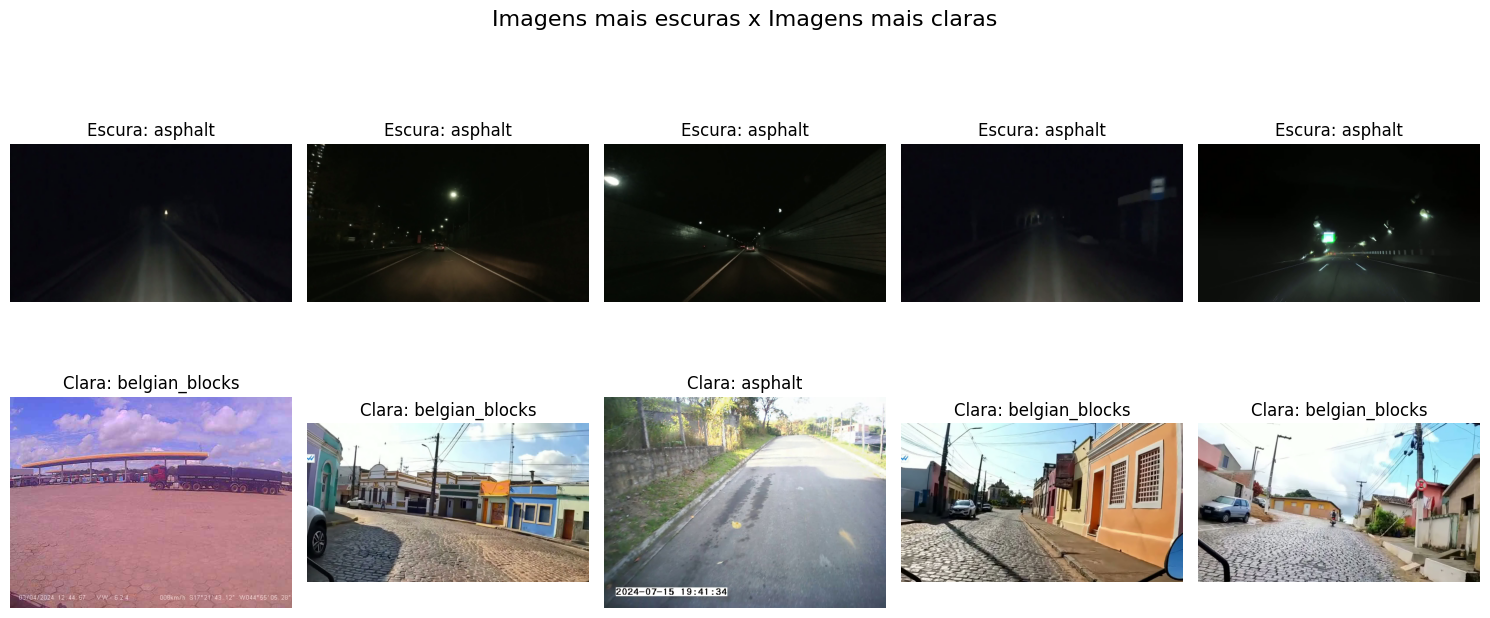

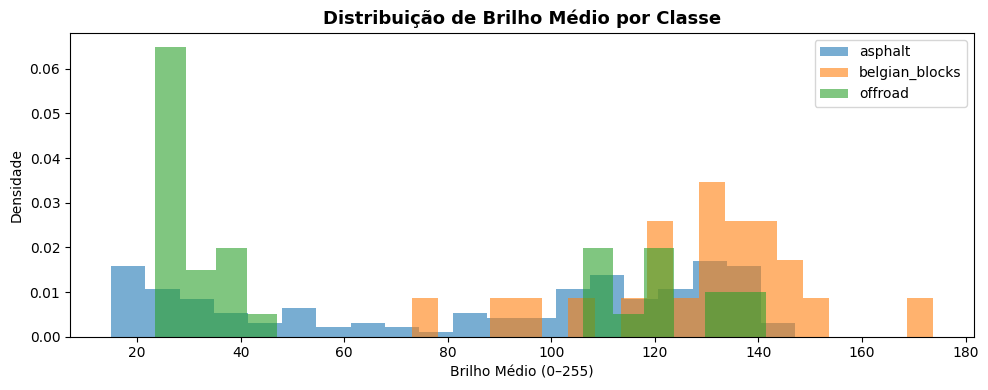

In [89]:
def extreme_analysis_images(data_dir, quantidade_amostras=5):
  # ESsa primeira parte só dei ctrl c ctrl v da função anterior
  classes = ['asphalt', 'belgian_blocks', 'offroad']
  path = data_dir+'/train'

  all_paths = []

  for cls in config['classes']:
      cls_dir = os.path.join(data_dir, 'train', cls)
      for fname in os.listdir(cls_dir):
          all_paths.append((os.path.join(cls_dir, fname), cls))

  random.shuffle(all_paths) # Embaralhar as imagens de acordo com a seed lá do início
  samples_to_analyze = all_paths[:200] # Pega as 100 primeiras imagens dentro da ordem aleatória do random.shuffle

  #A partir daqui o código diferencia da função passada.

  # Calcular o brilho médio da imagem e colocá-la numa ordem da mais escura até a mais clara
  brightness = []
  for path, cls in samples_to_analyze:
      try:
          img = Image.open(path).convert('L')
          b = np.mean(np.array(img))
          brightness.append((path, cls, b))
      except:
          pass

  brightness.sort(key=lambda x: x[2])

  dark_imgs = brightness[:quantidade_amostras]
  light_imgs = brightness[-quantidade_amostras:]

  # Configuração do gráfico e de plotagem

  fig, eixos = plt.subplots(2, quantidade_amostras, figsize=(15,7)) # figuras e eixos
  fig.suptitle('Imagens mais escuras x Imagens mais claras', fontsize=16)

  for indice in range(quantidade_amostras):
      # Desenhando as imagens escuras na primeira linha (índice 0)
      caminho_escura = dark_imgs[indice][0]
      imagem_escura = Image.open(caminho_escura)
      eixos[0, indice].imshow(imagem_escura)
      nome_da_classe_escura = caminho_escura.split('/')[-2] # Pega o nome da pasta
      eixos[0, indice].set_title(f"Escura: {nome_da_classe_escura}")
      eixos[0, indice].axis('off') # Esconde os eixos de números

      # Desenhando as imagens claras na segunda linha (índice 1)
      caminho_clara = light_imgs[indice][0]
      imagem_clara = Image.open(caminho_clara)
      eixos[1, indice].imshow(imagem_clara)
      nome_da_classe_clara = caminho_clara.split('/')[-2]
      eixos[1, indice].set_title(f"Clara: {nome_da_classe_clara}")
      eixos[1, indice].axis('off')

  plt.tight_layout()
  plt.show()

  # Distribuição de brilho por classe
  fig, ax = plt.subplots(figsize=(10, 4))
  for cls in config['classes']:
      cls_brightness = [b for nothing, c, b in brightness if c == cls]
      ax.hist(cls_brightness, bins=20, alpha=0.6, label=cls, density=True)
  ax.set_title('Distribuição de Brilho Médio por Classe', fontsize=13, fontweight='bold')
  ax.set_xlabel('Brilho Médio (0–255)')
  ax.set_ylabel('Densidade')
  ax.legend()
  plt.tight_layout()
  plt.show()

extreme_analysis_images(config['data_dir'])

`Leitura Rápida`

- As imagens mais escuras pertencem predominantemente à classe `asphalt`, o que indica uma correlação entre baixo brilho e asfalto.  Se o modelo aprender esse atalho, ele terá péssimo desempenho em casos de generalização (asfalto diurno, offroad noturno).
- Para resolver esse problema, as augmentations de `ColorJitter(brightness)` e `RandomAutocontrast` são **necessárias** para quebrar essa correlação e forçar o modelo a depender de textura, não de luminância global.

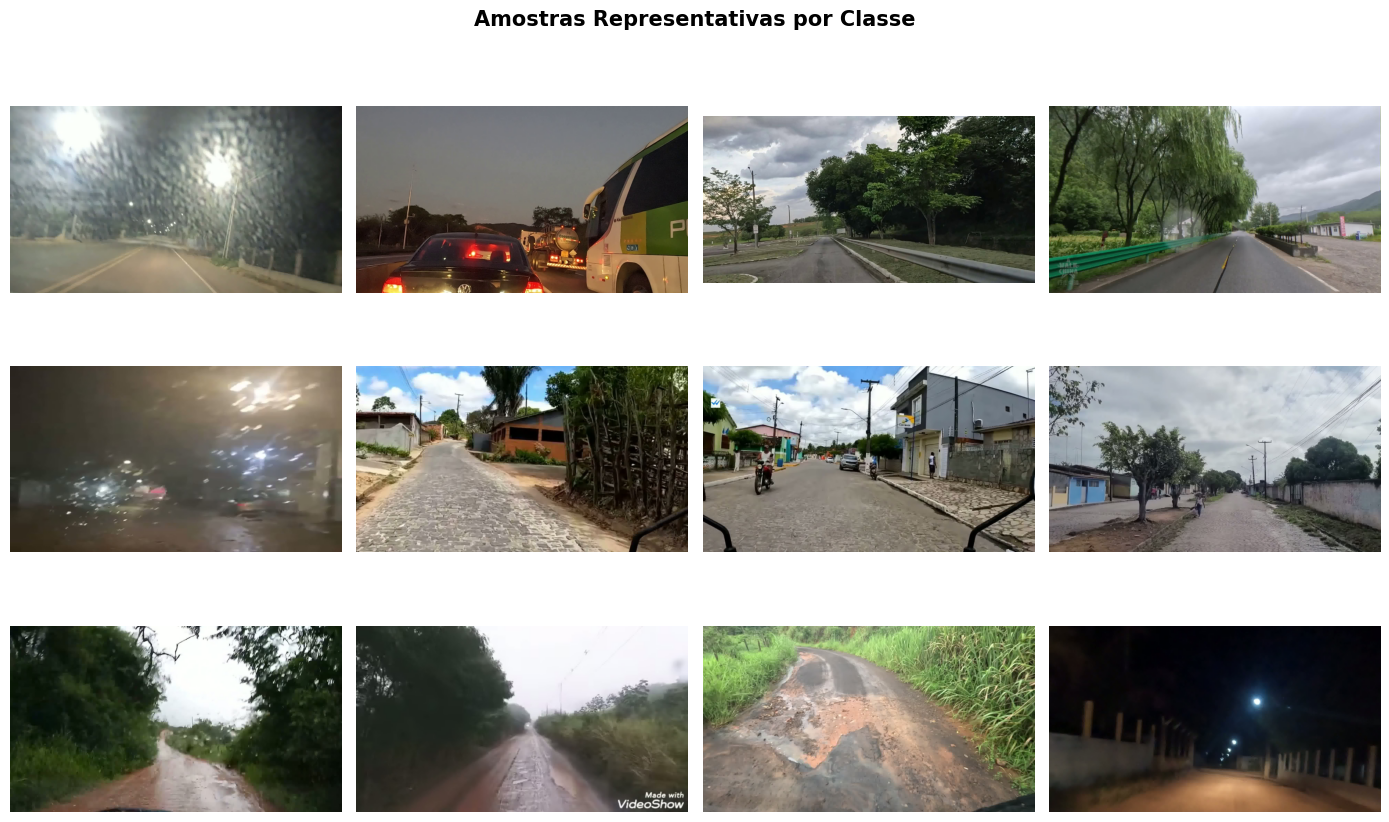

In [90]:
def show_class_samples(data_dir, n_per_class=4):

    fig, axes = plt.subplots(len(config['classes']), n_per_class, figsize=(14, 9))
    fig.suptitle('Amostras Representativas por Classe', fontsize=15, fontweight='bold')

    for row, cls in enumerate(config['classes']):
        cls_dir = os.path.join(data_dir, 'train', cls)
        imgs = random.sample(os.listdir(cls_dir), n_per_class)
        for col, fname in enumerate(imgs):
            img = Image.open(os.path.join(cls_dir, fname))
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(cls, fontsize=12, fontweight='bold',
                                          rotation=0, labelpad=80, va='center')
    plt.tight_layout()
    plt.show()

show_class_samples(config['data_dir'])

**Leitura IMPORTANTE — Características Visuais por Classe:**

- `asphalt`: superfície lisa, uniforme, geralmente cinza-escuro com marcações de faixa. A textura é **pouco estruturada** e de baixa frequência espacial.
- `belgian_blocks`: padrão de juntas entre blocos cria uma textura **altamente regular e repetitiva**, com linhas perpendiculares. Esta é a feature mais discriminativa, porém é um problema vulnerável à distorção de resize, ao ficar próxima da classe Asphalt.
- `offroad`: textura **irregular e não uniforme**, com variação de granulometria e cor que vai de marrom claro (areia) a cinza (pedregulho).

<a id='4'></a>
# 4. Pré-processamento e transformações de dados

> **Princípio de design dos pipelines**:  
> - **Treino**: augmentations estocásticas para aumentar diversidade artificial e prevenir overfitting.  
> - **Validação/Teste**: transformações **determinísticas**, uma vez que qualquer aleatoriedade no pipeline de teste tornaria as métricas não reproduzíveis e enviesaria a avaliação.
> - **Normalização ImageNet**: obrigatória para redes pré-treinadas. As redes utilizadas abaixo foram pré-treinadas com as métricas de normalização, então para obter melhor desempenho, utilizaremos elas.

In [91]:
# Normalização da ImageNet usada nos pipelines de forma tradicional
normal_mean = [0.485, 0.456, 0.406]
standard_mean = [0.229, 0.224, 0.225]

# ---- Pipeline do baseline ----:

baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(normal_mean, standard_mean),
])

# ---- Pipeline de treino com augmentation ----

train_transforms = transforms.Compose([
    transforms.Resize(256), # transforma pra 256px
    transforms.RandomResizedCrop(224, scale=(0.6,1.0), ratio=(0.8,1.25)), #Recorte(crop) aleatório

    # Augmentation baseado em variações da imagem, perspectiva, rotação
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    transforms.RandomRotation(degrees=15),

    #Augmentation baseado na iluminação, devido ao problema das imagens mais escuras
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.RandomAutocontrast(p=0.2),

    # Testando para ver se traz melhor resultado
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))
    ], p=0.2),

    # Conversão e normalização
    transforms.ToTensor(),
    transforms.Normalize(mean=normal_mean, std=standard_mean),

    # Apaga alguns patches aleatórios para evitar dependência e reduzir o overfitting
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3)),

])

# ---- Pipeline de avaliação determinístico(sem aleatoriedade) ----
val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=normal_mean, std=standard_mean)
])

<a id='5'></a>
# 5. Experimento 1 - Resnet18 (sem correção de desbalanceamento)

**Utilidade do Baseline**: Definir o desempenho mínimo e quantificar o viés induzido do dataset sem nenhuma intervenção.

**Por que ResNet-18?** É uma das arquiteturas mais leves da família ResNet (~11M parâmetros), adequada para um baseline rápido.

**Comportamento esperado**: O comportamento esperado é que o modelo aprenda a classificar tudo (ou quase tudo) como `asphalt`, obtendo alta acurácia mas F1-Macro muito baixo.

In [92]:
# Carregamento dos dados:

root_train = config['data_dir']+'/train'
root_test = config['data_dir']+'/test'

baseline_train_dataset = ImageFolder(root=root_train, transform=baseline_transforms)
baseline_test_dataset =  ImageFolder(root=root_test, transform=baseline_transforms)

baseline_train_dataloader = DataLoader(baseline_train_dataset,
                                 batch_size= config['batch_size'],
                                 shuffle=True,)

baseline_test_dataloader = DataLoader(baseline_test_dataset,
                                      batch_size=config['batch_size'],
                                      shuffle=False)

print(f'Classes: {baseline_train_dataset.classes}')
print(f'Imagens para treinamento: {len(baseline_train_dataset)}')
print(f'Imagens para teste:       {len(baseline_test_dataset)}')


Classes: ['asphalt', 'belgian_blocks', 'offroad']
Imagens para treinamento: 880
Imagens para teste:       300


In [93]:
baseline = resnet18(weights=ResNet18_Weights.DEFAULT)

baseline_features = baseline.fc.in_features

baseline.fc = nn.Linear(baseline_features, len(baseline_train_dataset.classes))

baseline_model = baseline.to(device)

#Cálculo da loss function e o otimizador

loss_baseline = nn.CrossEntropyLoss()

optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=config['learning_rate'])



# CrossEntropyLoss, Optimizer and Scheduler

In [94]:
# loss function, otimizador e scheduler da baseline

loss_baseline = nn.CrossEntropyLoss()

optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])

scheduler_baseline = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_baseline, mode='min', patience=config['patience_lr'])

# 6. Função de treinamento:

 A função abaixo é o núcleo de todos os experimentos. Ela registra, a cada época:

**1. Loss de treino/teste**: monitora a convergência e identifica overfitting (gap crescente entre as duas curvas).

**2. Acurácia**: exibida propositalmente para demonstrar que é uma métrica enganosa neste contexto.

**3. F1-Macro**: a métrica real que guia a seleção do melhor modelo (salvo via checkpoint).

O modelo salvo corresponde à **menor loss de teste** (não à menor loss de treino), prevenindo que um modelo em overfitting seja selecionado.

> As funções abaixo são **reutilizadas por todos os experimentos** — o mesmo código, os mesmos critérios. Isso garante que as comparações entre experimentos são justas.


In [95]:
def model_train(model, train_loader, test_loader, loss_function, optimizer, scheduler,
                epochs, device, save_path, experiment_name='exp'):
  print(f'Início do treino {experiment_name}\n\n')

  history = {'train_loss': [], 'test_loss': [],
             'train_acc': [], 'test_acc': [],
             'test_f1': []}

  best_test_loss = float('inf')

  for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

      images = images.to(device)
      labels = labels.to(device)

      # Reiniciar os gradientes do loop de antes
      optimizer.zero_grad()

      # Prevejo com base na imagem (Forward pass)
      prevision = model(images)

      # Calculo o erro
      loss = loss_function(prevision, labels)

      # Backpropagation para ajuste dosp esos
      loss.backward()

      # Atualização dos pesos
      optimizer.step()

      #Guardar as estatísticas
      running_loss += loss.item() * images.size(0)
      _, predicted = torch.max(prevision, 1) # só tenho interesse no predicted, esse "n" poderia facilmente ser qualquer outra variável, pq nn vou usá-lo
      correct += torch.sum(predicted==labels).item()
      total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validação e teste

    model.eval()
    test_loss_sum, test_correct, test_total = 0.0, 0, 0
    all_labels_list, all_preds_list = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images)
            loss = loss_function(preds, labels)
            test_loss_sum += loss.item() * images.size(0)
            _, predicted = torch.max(preds, 1)
            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)
            all_labels_list.extend(labels.cpu().numpy())
            all_preds_list.extend(predicted.cpu().numpy())

    test_loss = test_loss_sum / test_total
    test_acc  = test_correct / test_total
    test_f1   = f1_score(all_labels_list, all_preds_list, average='macro', zero_division=0)

    scheduler.step(test_loss)

    # Registro do histórico
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['test_f1'].append(test_f1)

    print(f"Ép {epoch+1:02d}/{epochs} | "
          f"Loss Treino: {train_loss:.4f} | Loss Teste: {test_loss:.4f} | "
          f"Acc Teste: {test_acc:.3f} | F1-Macro: {test_f1:.3f}")

    # Salva o melhor modelo
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), save_path)
        print(f" Novo melhor modelo em '{save_path}' (loss={test_loss:.4f})")

  print(f"Treinamento concluído. Melhor loss de teste: {best_test_loss:.4f}\n")
  return history

In [96]:
def plot_training_curves(history, title='Curvas de Aprendizado'):

    #- Overfitting: gap crescente entre treino e teste
    #- Underfitting: ambas as curvas com loss alta
    #- Convergência prematura: plateau antes das épocas finais

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Treino', markersize=4)
    axes[0].plot(epochs, history['test_loss'],  'r-o', label='Teste',  markersize=4)
    axes[0].set_title('Loss por Época', fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Acurácia
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Treino', markersize=4)
    axes[1].plot(epochs, history['test_acc'],  'r-o', label='Teste',  markersize=4)
    axes[1].set_title('Acurácia por Época\n(Demonstração de como é uma métrica enganosa foco em ver o F1-Macro)', fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # F1-Macro
    axes[2].plot(epochs, history['test_f1'], 'g-o', label='F1-Macro (Teste)', markersize=4)
    axes[2].axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='Baseline aleatório')
    axes[2].set_title('F1-Macro no Teste por Época\n(Métrica principal)', fontweight='bold')
    axes[2].set_xlabel('Época')
    axes[2].set_ylabel('F1-Macro')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    axes[2].set_ylim(0, 1)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [97]:
def evaluate_model(model, test_loader, class_names, device, title='Avaliação do Modelo'):

    # Avaliação completa do modelo: matriz de confusão normalizada e
    # classification report com F1, Precision e Recall por classe.

    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Avaliando', leave=False):
            images, labels = images.to(device), labels.to(device)
            preds = model(images)
            nb, predicted = torch.max(preds, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    # Matrizes de confusão (absoluta e normalizada)
    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title}\nMatriz de Confusão (Contagens Absolutas)', fontweight='bold')
    axes[0].set_xlabel('Classe Prevista')
    axes[0].set_ylabel('Classe Real')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title}\nMatriz de Confusão (Normalizada — Recall)', fontweight='bold')
    axes[1].set_xlabel('Classe Prevista')
    axes[1].set_ylabel('Classe Real')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print(f"  {title} — Relatório Detalhado")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

    # Balanced accuracy
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    f1_mac  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    print(f"Balanced Accuracy : {bal_acc:.3f}")
    print(f"F1-Macro          : {f1_mac:.3f}")
    return {'balanced_acc': bal_acc, 'f1_macro': f1_mac,
            'report': classification_report(all_labels, all_preds,
                                            target_names=class_names,
                                            output_dict=True, digits=3)}

In [98]:
history_baseline=model_train(
    model=baseline_model,
    train_loader=baseline_train_dataloader,
    test_loader=baseline_test_dataloader,
    loss_function=loss_baseline,
    optimizer=optimizer_baseline,
    scheduler=scheduler_baseline,
    epochs=10,
    device=config['device'],
    save_path='baseline_resnet18.pth',
    experiment_name='Experimento 1 - Baseline Resnet18.pth'
)

Início do treino Experimento 1 - Baseline Resnet18.pth




100%|██████████| 28/28 [00:29<00:00,  1.07s/it]


Ép 01/10 | Loss Treino: 0.3132 | Loss Teste: 0.3399 | Acc Teste: 0.907 | F1-Macro: 0.735
 Novo melhor modelo em 'baseline_resnet18.pth' (loss=0.3399)


100%|██████████| 28/28 [00:34<00:00,  1.22s/it]


Ép 02/10 | Loss Treino: 0.0270 | Loss Teste: 0.2105 | Acc Teste: 0.927 | F1-Macro: 0.803
 Novo melhor modelo em 'baseline_resnet18.pth' (loss=0.2105)


...

Ép 08/10 | Loss Treino: 0.0052 | Loss Teste: 0.2649 | Acc Teste: 0.927 | F1-Macro: 0.801


100%|██████████| 28/28 [00:18<00:00,  1.51it/s]


Ép 09/10 | Loss Treino: 0.0093 | Loss Teste: 0.3448 | Acc Teste: 0.887 | F1-Macro: 0.735


100%|██████████| 28/28 [00:17<00:00,  1.57it/s]


Ép 10/10 | Loss Treino: 0.0042 | Loss Teste: 0.2995 | Acc Teste: 0.910 | F1-Macro: 0.791
Treinamento concluído. Melhor loss de teste: 0.1898



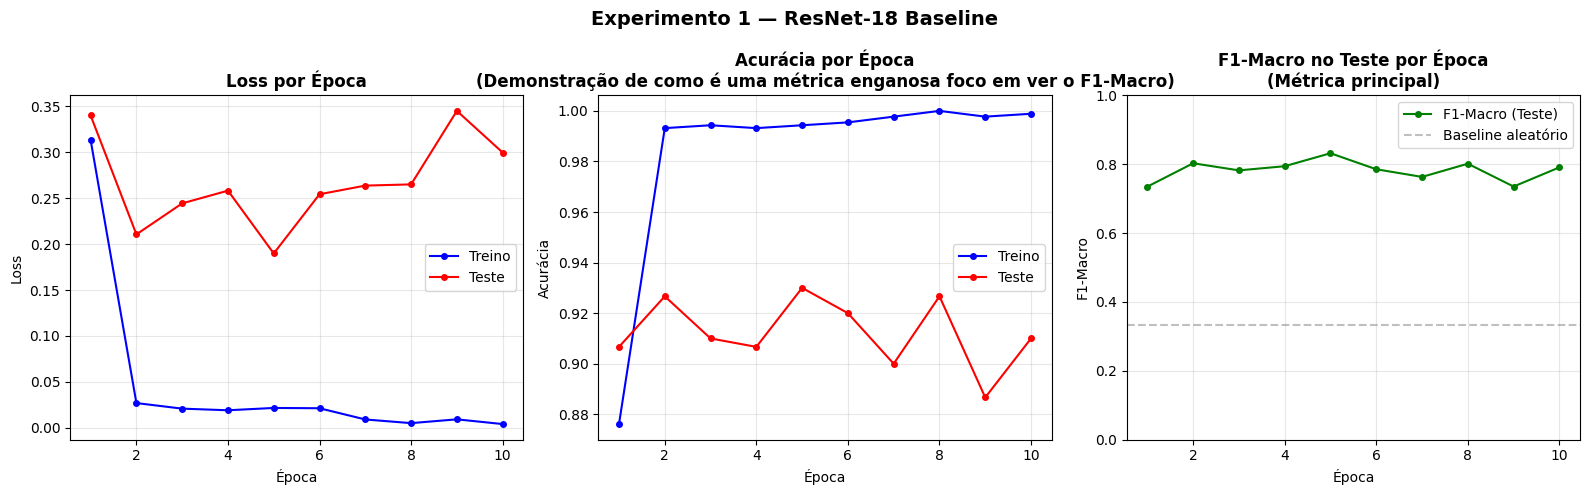

In [99]:
plot_training_curves(history_baseline, 'Experimento 1 — ResNet-18 Baseline')


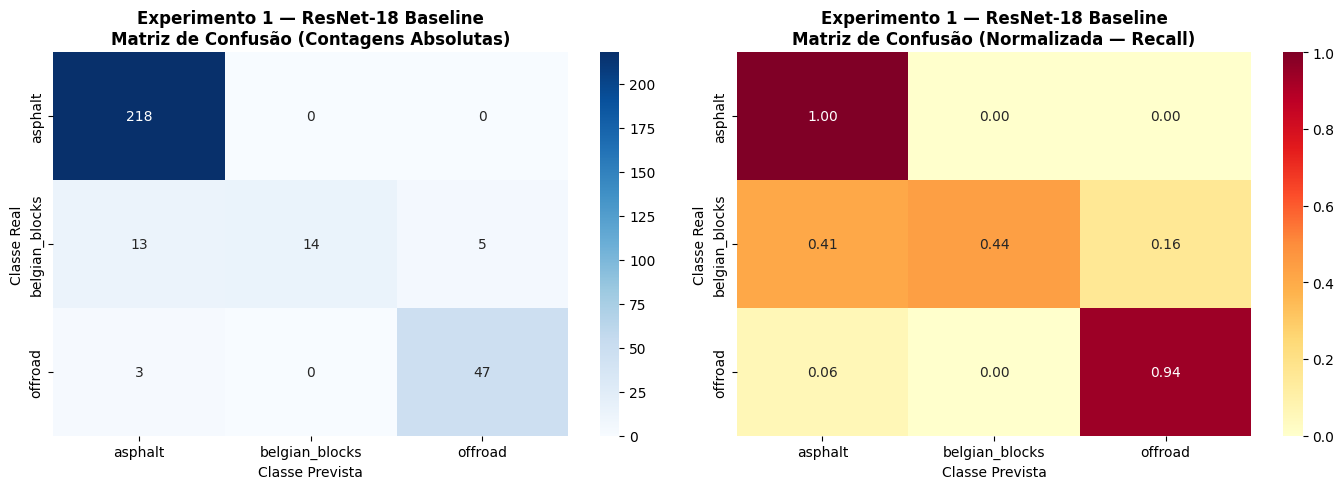


  Experimento 1 — ResNet-18 Baseline — Relatório Detalhado
                precision    recall  f1-score   support

       asphalt      0.932     1.000     0.965       218
belgian_blocks      1.000     0.438     0.609        32
       offroad      0.904     0.940     0.922        50

      accuracy                          0.930       300
     macro avg      0.945     0.792     0.832       300
  weighted avg      0.934     0.930     0.919       300

Balanced Accuracy : 0.792
F1-Macro          : 0.832


In [100]:
baseline_model.load_state_dict(torch.load('baseline_resnet18.pth'))
results_baseline = evaluate_model(
    model=baseline_model,
    test_loader=baseline_test_dataloader,
    class_names=config['classes'],
    device=device,
    title='Experimento 1 — ResNet-18 Baseline'
)

**📊 Análise Crítica — Matriz de Confusão do Baseline + Curvas de aprendizado:**

- **Overfitting claro**: a loss de treino colapsa para aproximadamente 0.02 a partir da 3ª–4ª época, enquanto a loss de teste oscila e permanece muito mais alta. Com apenas 880 imagens e ~11M parâmetros treináveis, a rede memoriza o conjunto de treino rapidamente.

- **Viés confirmado**: a grande maioria dos erros consiste em amostras de `belgian_blocks` e `offroad` sendo classificadas como `asphalt`. O recall de `asphalt` é próximo de 1.0, enquanto o recall de `belgian_blocks` está 0.469

- **Interpretação econômica do aprendizado**: do ponto de vista da função de perda, errar um `belgian_blocks` (aproximadamente apenas 11% das amostras) custa apenas 11% do peso de errar um `asphalt`. O modelo racionalmente aprende que "chutar asfalto" é a estratégia ótima para minimizar a CrossEntropyLoss não ponderada.

- **Próximo passo**: introduzir pesos na loss function para deixar mais equiparado o custo de errar qualquer classe, independentemente da sua frequência.


<a id='7'></a>
# 7. Experimento 2 — ResNet-50 com Weighted CrossEntropyLoss

O modelo da forma que está atualmente penaliza todos os erros com um mesmo **peso**. Como existem muito mais imagens de asfalto, errar um paralelepípedo "custa pouco" para a rede durante o treino. A **hipótese** que será testada logo em seguida é: atribuir pesos maiores para erros nas classes minoritárias diretamente na função de custo (CrossEntropyLoss) e forçar o modelo a prestar mais atenção nos bridge_blocks.

**Mudanças em relação ao Baseline**:
1. **Arquitetura**: ResNet-18 → **ResNet-50** (~25M parâmetros), com cabeça classificadora ampliada (`Linear→BN→ReLU→Dropout→Linear`) para maior capacidade representacional.

2. **Loss Function**: `CrossEntropyLoss` sem pesos → `CrossEntropyLoss` com **pesos inversamente proporcionais à frequência**.

3. **Fine-tuning seletivo**: apenas `layer4` e `fc` são treináveis, congelando as camadas iniciais (features de baixo nível já bem aprendidas no ImageNet).

In [101]:
# Aplicação dos pesos = pesos inversamente proporcionais a frequência  // MUDAR RESNET%)

weight_asphalt = 1.0 / quantidade_asphalt
weight_belgian = 1.0 / quantidade_belgian
weight_offroad = 1.0 / quantidade_offroad

# bse = baseline // Vou diminuir a quantidade de letras para ficar mais fácil e rápido de digitar.

# Configuração do teste com o resnet50, assumiu o nome de bse2.
global_weights = torch.tensor([weight_asphalt, weight_belgian, weight_offroad], dtype=torch.float).to(config['device']) # Atualização de pesos para usar para sempre.

print("Pesos de classe:")
for classe, weight in zip(config['classes'], global_weights):
    print(f"  {classe:<20}: {weight:.4f}")
print(f"\nRazão de peso max/min: {global_weights.max()/global_weights.min():.1f}x")




Pesos de classe:
  asphalt             : 0.0016
  belgian_blocks      : 0.0106
  offroad             : 0.0066

Razão de peso max/min: 6.8x


In [102]:

bse2_exp = resnet50(weights=ResNet50_Weights.DEFAULT)

for name, parametro in baseline.named_parameters():
  if "layer4" in name or "fc" in name:
    parametro.requires_grad = True
  else:
    parametro.requires_grad = False

bse2_features = bse2_exp.fc.in_features

# TRoquei de linear para um container de módulos na resnet usando o **sequential**
bse2_exp.fc = nn.Sequential(nn.Linear(bse2_features, 512),
                            nn.BatchNorm1d(512),
                            nn.ReLU(),
                            nn.Dropout(0,3),
                            nn.Linear(512, len(baseline_train_dataset.classes)))



bse2_model = bse2_exp.to(device)

In [104]:
# loss function, otimizador e scheduler da baseline

loss_bse2 = nn.CrossEntropyLoss(weight=global_weights)

optimizer_bse2 = optim.Adam(bse2_model.parameters(), lr= config['learning_rate'])

scheduler_bse2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_bse2, mode='min', patience=config['patience_lr'])

# Treinamento do modelo
history_exp2 = model_train(
    model=bse2_model,
    train_loader=baseline_train_dataloader,
    test_loader=baseline_test_dataloader,
    loss_function=loss_bse2,
    optimizer=optimizer_bse2,
    scheduler=scheduler_bse2,
    epochs=10,
    device=config['device'],
    save_path='resnet50_weighted.pth',
    experiment_name='Experimento 2 - Resnet50 com Pesos'
)



Início do treino Experimento 2 - Resnet50 com Pesos




100%|██████████| 28/28 [00:28<00:00,  1.03s/it]


Ép 01/10 | Loss Treino: 0.4351 | Loss Teste: 0.5511 | Acc Teste: 0.823 | F1-Macro: 0.672
 Novo melhor modelo em 'resnet50_weighted.pth' (loss=0.5511)


100%|██████████| 28/28 [00:23<00:00,  1.17it/s]


Ép 02/10 | Loss Treino: 0.0904 | Loss Teste: 0.4461 | Acc Teste: 0.853 | F1-Macro: 0.762
 Novo melhor modelo em 'resnet50_weighted.pth' (loss=0.4461)


...

Ép 08/10 | Loss Treino: 0.0096 | Loss Teste: 0.2923 | Acc Teste: 0.903 | F1-Macro: 0.814


100%|██████████| 28/28 [00:24<00:00,  1.15it/s]


Ép 09/10 | Loss Treino: 0.0074 | Loss Teste: 0.3219 | Acc Teste: 0.887 | F1-Macro: 0.771


100%|██████████| 28/28 [00:24<00:00,  1.16it/s]


Ép 10/10 | Loss Treino: 0.0062 | Loss Teste: 0.2890 | Acc Teste: 0.890 | F1-Macro: 0.776
Treinamento concluído. Melhor loss de teste: 0.2694



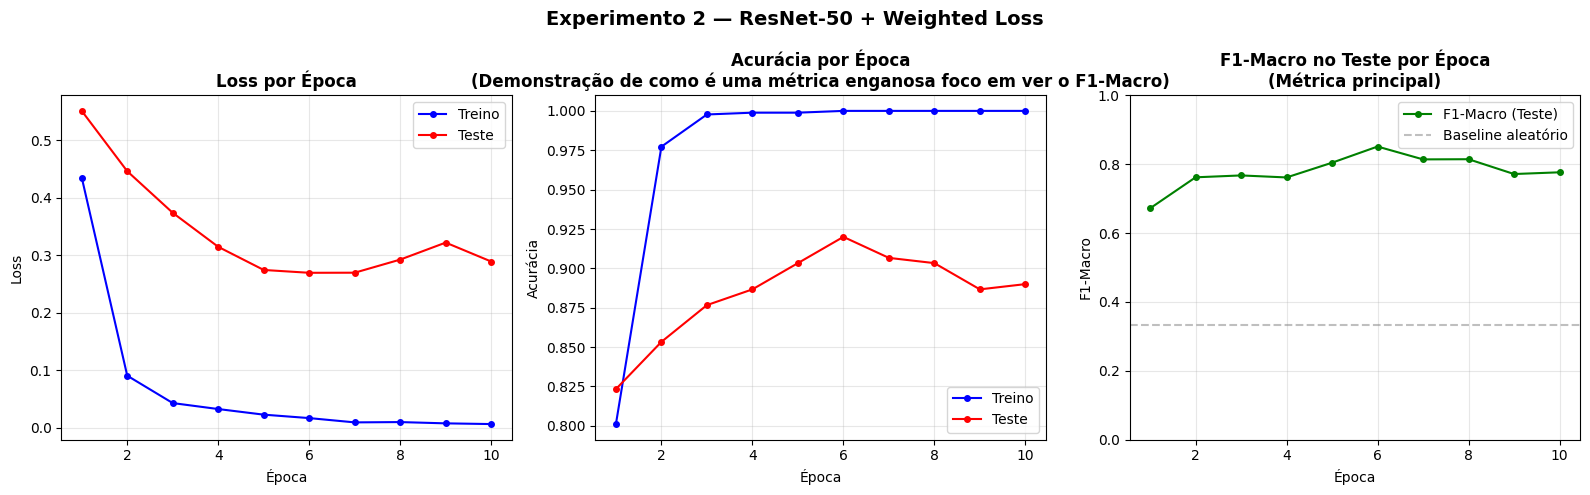

In [105]:
plot_training_curves(history_exp2, 'Experimento 2 — ResNet-50 + Weighted Loss')


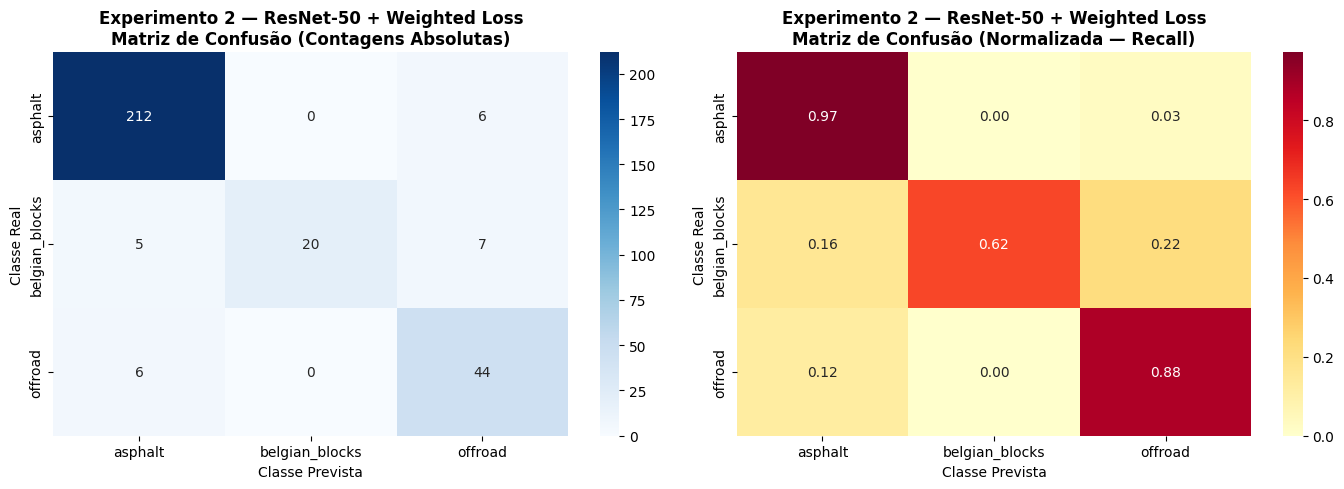


  Experimento 2 — ResNet-50 + Weighted Loss — Relatório Detalhado
                precision    recall  f1-score   support

       asphalt      0.951     0.972     0.961       218
belgian_blocks      1.000     0.625     0.769        32
       offroad      0.772     0.880     0.822        50

      accuracy                          0.920       300
     macro avg      0.908     0.826     0.851       300
  weighted avg      0.926     0.920     0.918       300

Balanced Accuracy : 0.826
F1-Macro          : 0.851


In [106]:
# Avaliação da matriz de confusão com o baseline:

bse2_model.load_state_dict(torch.load('resnet50_weighted.pth'))
results_exp2 = evaluate_model(
    model=bse2_model,
    test_loader=baseline_test_dataloader,
    class_names=config['classes'],
    device=device,
    title='Experimento 2 — ResNet-50 + Weighted Loss'
)

**📊 Análise Crítica — Weighted Loss:**

- **Melhora observada**: o F1 de `belgian_blocks` aumentou um pouco em relação ao baseline, pois o gradiente de um erro nesta classe agora pesa ~6,8× mais na atualização dos pesos. O modelo se forçou mais a aprender features visuais reais dos blocos, não apenas o atalho "prever asfalto", porém ainda não foi o suficiente.

- **Overfitting ainda presente**: com dataset pequeno e rede profunda, o gap treino-teste persiste. O próximo experimento adicionará data augmentation para atacar este problema.


<a id='8'></a>
## 8. Experimento 3 — ResNet-50 com Data Augmentation e Pesos

> A **hipótese** é combinar weighted loss com data augmentation robusto para simultaneamente (a) corrigir o viés de classe e (b) reduzir o overfitting ao aumentar artificialmente a diversidade do dataset de treino.

> **Mudanças em relação ao Experimento 2**:
> 1. **Pipeline de treino**: substitui o Resize(224,224) direto pelo pipeline com CenterCrop, ColorJitter, RandomPerspective e RandomErasing.
> 2. **Manutenção dos pesos**: mantém a weighted loss do Experimento 2.
> 3. **Arquitetura idêntica**: mesma ResNet-50 com cabeça ampliada.
> 4. **Épocas aumentadas (10 -> 15)**: O data augmentation expande o dataset e o modelo vê imagens diferentes a cada época, adiando a convergência.



In [110]:

# Dataloaders augmentados

bline3_train = ImageFolder(root=root_train, transform=train_transforms)
bline3_test =  ImageFolder(root=root_test, transform=val_test_transforms)

bline3_train_loader = DataLoader(bline3_train,
                                 batch_size= config['batch_size'],
                                 shuffle=True,
                                 num_workers=config['num_workers'])

bline3_test_loader = DataLoader(bline3_test,
                                batch_size=config['batch_size'],
                                shuffle=False,
                                num_workers=config['num_workers'])

# Criação do modelo de treino 3
bline3_exp = resnet50(weights=ResNet50_Weights.DEFAULT)

for nome, param in bline3_exp.named_parameters():
  if 'layer4' in nome or 'fc' in nome:
    param.requires_grad = True
  else:
    param.requires_grad = False

bline3_features = bline3_exp.fc.in_features

bline3_exp.fc = nn.Sequential(nn.Linear(bline3_features, 512),
                              nn.BatchNorm1d(512),
                              nn.ReLU(),
                              nn.Dropout(0.3),
                              nn.Linear(512, len(config['classes'])))

bline3_model = bline3_exp.to(device)

# Loss, optmiizer e scheduler

loss_bline3 = nn.CrossEntropyLoss(weight=global_weights)

# esse filter(lambda p: p.requires_grad...) faz com que o otimizador Adam enxergue apenas os parâmetros importantes que não foram congelados
optimizer_bline3 = optim.Adam(filter(lambda p: p.requires_grad, bline3_model.parameters()),
                              lr=config['learning_rate'], weight_decay=config['weight_decay'])

scheduler_bline3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_bline3, mode='min', patience=5)


In [111]:
# Treino do "3 modelo"
history_exp3 = model_train(
    model=bline3_model,
    train_loader=bline3_train_loader,
    test_loader=bline3_test_loader,
    loss_function=loss_bline3,
    optimizer=optimizer_bline3,
    scheduler=scheduler_bline3,
    epochs=15,
    device=config['device'],
    save_path='resnet50_augmentation.pth',
    experiment_name='Experimento 3 - Resnet50 com peso e data augmentation'
)

Início do treino Experimento 3 - Resnet50 com peso e data augmentation




100%|██████████| 28/28 [00:25<00:00,  1.09it/s]


Ép 01/15 | Loss Treino: 0.6344 | Loss Teste: 0.8728 | Acc Teste: 0.647 | F1-Macro: 0.559
 Novo melhor modelo em 'resnet50_augmentation.pth' (loss=0.8728)


100%|██████████| 28/28 [00:26<00:00,  1.05it/s]


Ép 02/15 | Loss Treino: 0.2842 | Loss Teste: 0.6477 | Acc Teste: 0.767 | F1-Macro: 0.632
 Novo melhor modelo em 'resnet50_augmentation.pth' (loss=0.6477)


...

Ép 13/15 | Loss Treino: 0.0269 | Loss Teste: 0.2105 | Acc Teste: 0.927 | F1-Macro: 0.875
 Novo melhor modelo em 'resnet50_augmentation.pth' (loss=0.2105)


100%|██████████| 28/28 [00:23<00:00,  1.18it/s]


Ép 14/15 | Loss Treino: 0.0286 | Loss Teste: 0.2331 | Acc Teste: 0.907 | F1-Macro: 0.831


100%|██████████| 28/28 [00:23<00:00,  1.18it/s]


Ép 15/15 | Loss Treino: 0.0249 | Loss Teste: 0.2940 | Acc Teste: 0.907 | F1-Macro: 0.832
Treinamento concluído. Melhor loss de teste: 0.2105



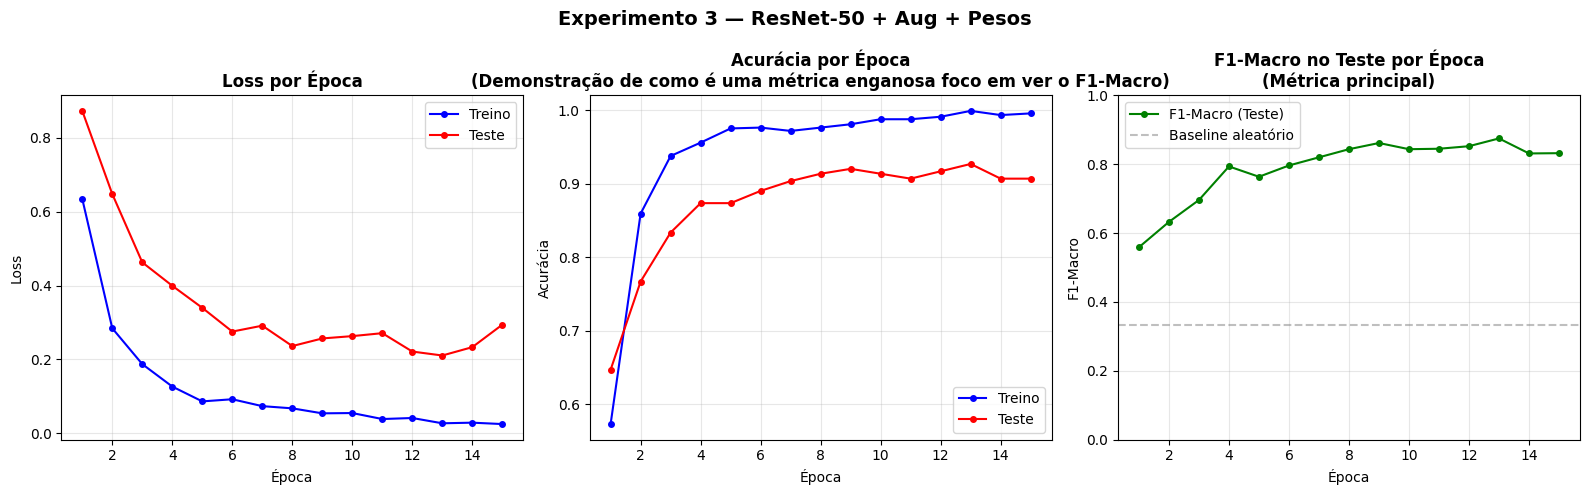

In [112]:
# Avaliação da matriz de confusão
plot_training_curves(history_exp3, 'Experimento 3 — ResNet-50 + Aug + Pesos')


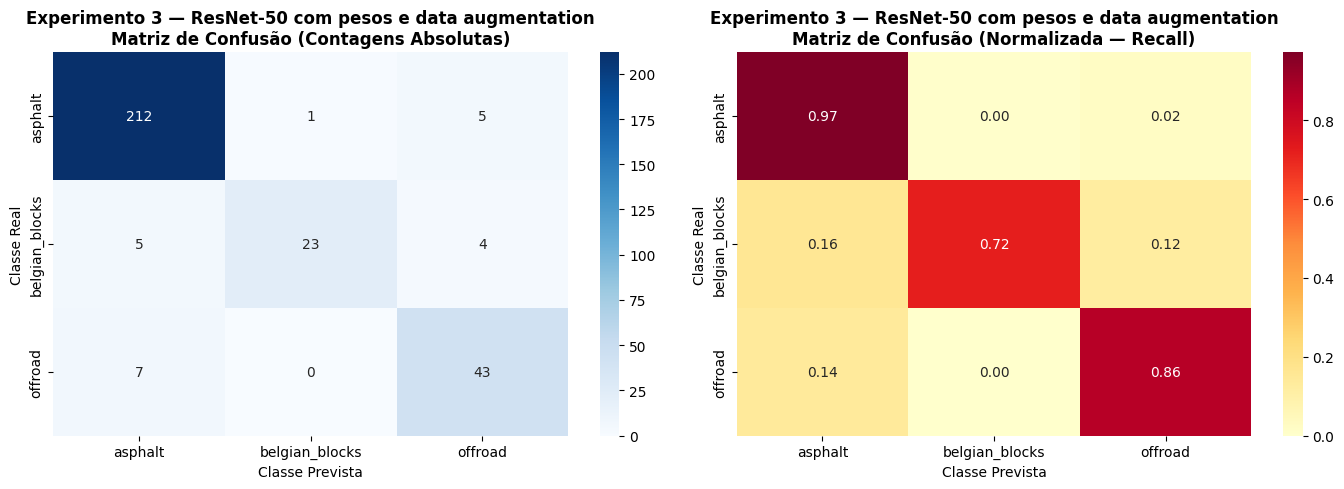


  Experimento 3 — ResNet-50 com pesos e data augmentation — Relatório Detalhado
                precision    recall  f1-score   support

       asphalt      0.946     0.972     0.959       218
belgian_blocks      0.958     0.719     0.821        32
       offroad      0.827     0.860     0.843        50

      accuracy                          0.927       300
     macro avg      0.911     0.850     0.875       300
  weighted avg      0.928     0.927     0.925       300

Balanced Accuracy : 0.850
F1-Macro          : 0.875


In [114]:
bline3_model.load_state_dict(torch.load('resnet50_augmentation.pth'))
results_exp3 = evaluate_model(
    model=bline3_model,
    test_loader=bline3_test_loader,
    class_names=config['classes'],
    device=device,
    title='Experimento 3 — ResNet-50 com pesos e data augmentation'
)


## **Análise Crítica — Data Augmentation:**

- **Efeito reparado no problema do overfitting**: a loss de treino caiu mais lentamente, pois o modelo vê cada imagem de forma ligeiramente diferente em cada época.

- **Efeito na generalização**: o modelo performou muito melhor em condições de iluminação variada, pois foi exposto a essas variações durante o treino.

- **Comparação justa**: ao usar `val_test_transforms` no teste (e não `treino_transforms`), foi garantido que a avaliação é estritamente determinística e comparável entre todos os experimentos.


<a id='9'></a>
## 9. Experimento 4 — EfficientNet-B0

> **Motivo**: a família EfficientNet foi projetada para otimizar o trade-off entre acurácia e eficiência computacional. O EfficientNet-B0 tem aproximadamente 5.3M parâmetros, menos da metade da ResNet-18 e um pouco mais de 1/5 dos parâmetros da ResNet-50, mas em alguns casos supera a ResNet-50 em benchmarks de ImageNet com menos parâmetros.
>
> **Hipótese**: o EfficientNet-B0, com sua arquitetura MBConv (Mobile Inverted Bottleneck), captura features de textura em múltiplas escalas de maneira mais eficiente, o que pode ser benéfico para discriminar as três classes de superfície.
>
> **Mudanças**: apenas a camada classificadora final é substituída. O extrator de features permanece congelado para evitar overfitting.


In [115]:
model_efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for param in model_efficientnet.features.parameters():
  param.requires_grad = False

num_features_eff = model_efficientnet.classifier[1].in_features

model_efficientnet.classifier[1] = nn.Linear(num_features_eff, len(config['classes']))

model_efficientnet = model_efficientnet.to(device)

In [116]:
eff_train = ImageFolder(root=root_train, transform=train_transforms)
eff_test =  ImageFolder(root=root_test, transform=train_transforms)

eff_train_loader = DataLoader(eff_train,
                             batch_size= config['batch_size'],
                             shuffle=True,)

eff_test_loader = DataLoader(eff_test,
                             batch_size=config['batch_size'],
                             shuffle=False)

loss_eff = nn.CrossEntropyLoss(weight=global_weights)
optimizer_eff = optim.Adam(model_efficientnet.classifier.parameters(), lr=0.001)
scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_eff, mode='min', patience=5)




Início do treino Experimento 4 - EfficientNet-B0




100%|██████████| 28/28 [00:29<00:00,  1.04s/it]


Ép 01/10 | Loss Treino: 0.6595 | Loss Teste: 0.7106 | Acc Teste: 0.740 | F1-Macro: 0.602
 Novo melhor modelo em 'efficientnet_b0.pth' (loss=0.7106)


100%|██████████| 28/28 [00:29<00:00,  1.06s/it]


Ép 02/10 | Loss Treino: 0.4525 | Loss Teste: 0.6531 | Acc Teste: 0.733 | F1-Macro: 0.579
 Novo melhor modelo em 'efficientnet_b0.pth' (loss=0.6531)


...

Ép 08/10 | Loss Treino: 0.2653 | Loss Teste: 0.5277 | Acc Teste: 0.787 | F1-Macro: 0.619
 Novo melhor modelo em 'efficientnet_b0.pth' (loss=0.5277)


100%|██████████| 28/28 [00:28<00:00,  1.03s/it]


Ép 09/10 | Loss Treino: 0.2490 | Loss Teste: 0.5548 | Acc Teste: 0.743 | F1-Macro: 0.607


100%|██████████| 28/28 [00:29<00:00,  1.05s/it]


Ép 10/10 | Loss Treino: 0.2407 | Loss Teste: 0.5786 | Acc Teste: 0.730 | F1-Macro: 0.584
Treinamento concluído. Melhor loss de teste: 0.5277



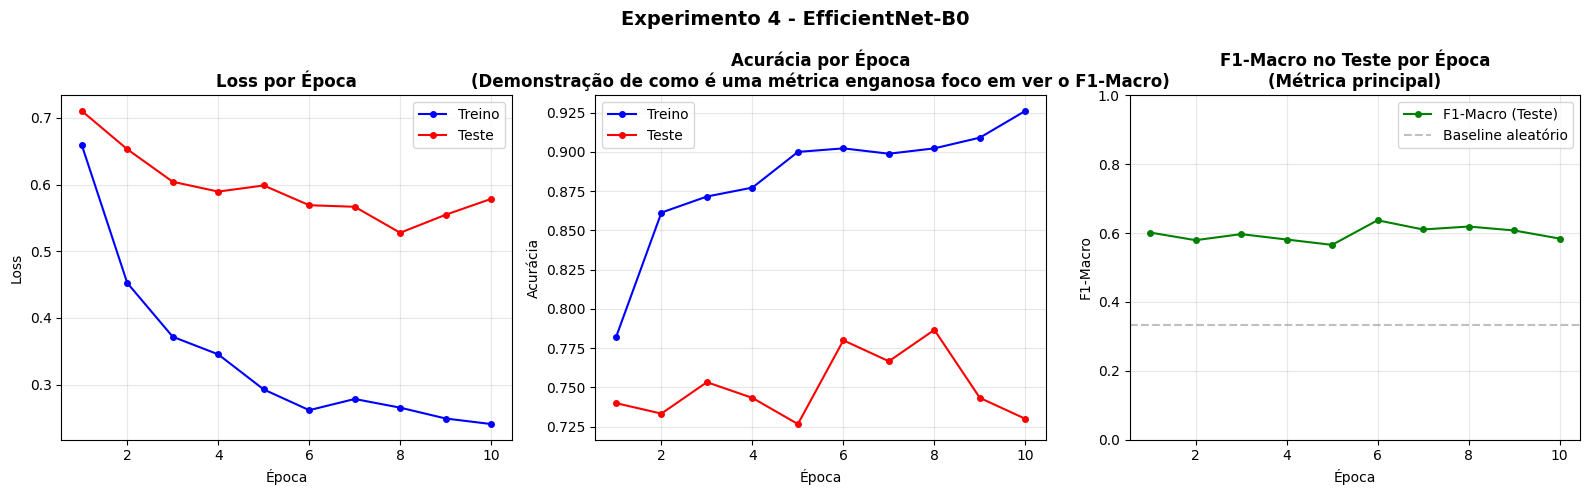

In [119]:
history_exp4= model_train(
    model=model_efficientnet,
    train_loader=eff_train_loader,
    test_loader=eff_test_loader,
    loss_function=loss_eff,
    optimizer=optimizer_eff,
    scheduler=scheduler_eff,
    epochs=10,
    device=config['device'],
    save_path='efficientnet_b0.pth',
    experiment_name='Experimento 4 - EfficientNet-B0'
)

plot_training_curves(history_exp4, 'Experimento 4 - EfficientNet-B0')


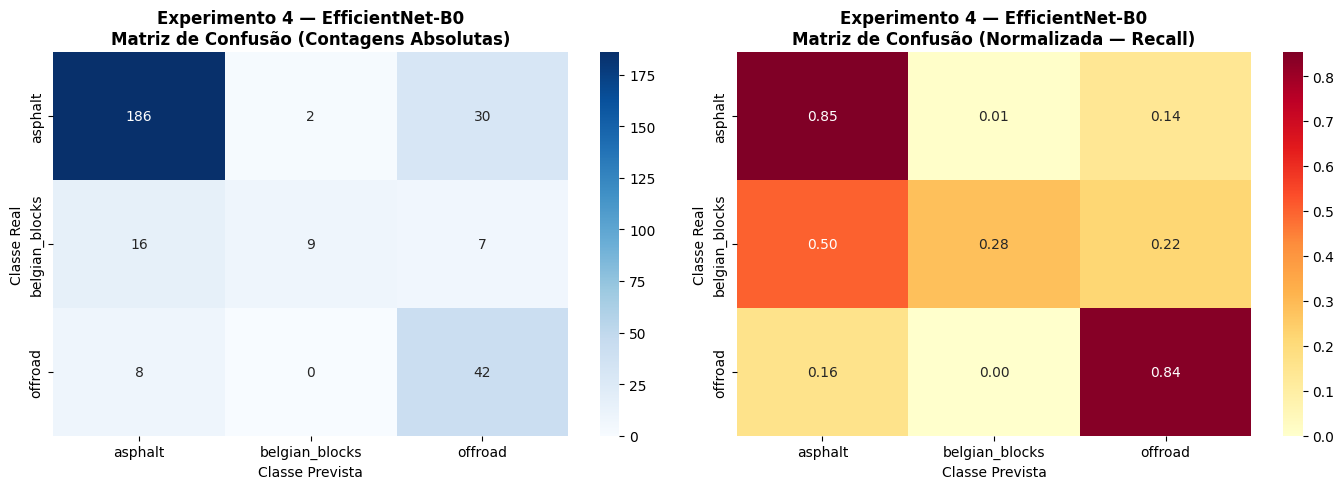


  Experimento 4 — EfficientNet-B0 — Relatório Detalhado
                precision    recall  f1-score   support

       asphalt      0.886     0.853     0.869       218
belgian_blocks      0.818     0.281     0.419        32
       offroad      0.532     0.840     0.651        50

      accuracy                          0.790       300
     macro avg      0.745     0.658     0.646       300
  weighted avg      0.819     0.790     0.785       300

Balanced Accuracy : 0.658
F1-Macro          : 0.646


In [120]:
model_efficientnet.load_state_dict(torch.load('efficientnet_b0.pth'))
results_exp4 = evaluate_model(
    model=model_efficientnet,
    test_loader=eff_test_loader,
    class_names=config['classes'],
    device=device,
    title='Experimento 4 — EfficientNet-B0'
)


<a id='10'></a>
## 10. Análise de Interpretabilidade com Grad-CAM

> Gradient-weighted Class Activation Mapping (Grad-CAM) usa os gradientes da classe alvo que fluem pela última camada convolucional para produzir um mapa de calor que indica **onde na imagem o modelo focou** para tomar sua decisão. O Grad-CAM permite verificar se o modelo está aprendendo as features semanticamente corretas (textura da superfície, padrão dos blocos) ou se está tomando atalhos (bordas da imagem, iluminação global, artefatos de compressão).
>
> **Interpretaçao do grad-cam:**  
> - 🔴 Regiões quentes (vermelho): alta ativação, o modelo presta atenção aqui.  
> - 🔵 Regiões frias (azul): baixa ativação, o modelo ignora esta região.  
> - **Bom sinal**: ativação concentrada na textura central da superfície.  
> - **Sinal ruim**: ativação nas bordas da imagem, no céu, em veículos ao fundo.


In [139]:
# Visualização com grad-cam


def visualization_grad_cam(model, dataset_test, device, quantity=5,title='Grad_cam'):

  model.eval()
  #Uso do método hasattr para pdoer colocar tanto resnet quanto efficientNet sem problemas
  if hasattr(model, 'layer4'):
      # Funciona para ResNet, ResNeXt, WideResNet, etc.
      layer_target = [model.layer4[-1]]
  elif hasattr(model, 'features'):
      # Funciona para EfficientNet, MobileNet, VGG, DenseNet, etc.
      for param in model.features.parameters():
            param.requires_grad_(True)
      layer_target = [model.features[-1]]
  else:
      layer_target = [list(model.children())[-2]]


  heat_cam = GradCAM(model=model, target_layers=layer_target)

  fig, eixos = plt.subplots(2, quantity, figsize=(16,8))
  fig.suptitle('Grad-CAM: Análise de para onde o modelo olha', fontsize=16)

  idx_random = np.random.choice(len(dataset_test), quantity, replace=False)

  for column, index in enumerate(idx_random):
    img_tensor, real_label = dataset_test[index]

    batch_tensor = img_tensor.unsqueeze(0).to(device)

    target = [ClassifierOutputTarget(real_label)]
    grad_cam_img = heat_cam(input_tensor=batch_tensor, targets=target)

    grad_cam_2d = grad_cam_img[0, :]

    normal_mean = np.array([0.485, 0.456, 0.406])
    standard_mean = np.array([0.229, 0.224, 0.225])

    origin_image = img_tensor.cpu().numpy().transpose(1, 2, 0)
    origin_image = standard_mean * origin_image + normal_mean
    origin_image = np.clip(oriInterpretativagin_image, 0, 1) # pixels entre 0 e 1

    img_with_map = show_cam_on_image(origin_image, grad_cam_2d, use_rgb=True)

    real_label_name = dataset_test.classes[real_label]

    model.eval()

    with torch.no_grad():
      prevision = model(batch_tensor)
      ni, predicted_class = torch.max(prevision, 1)
      predicted_class_name = dataset_test.classes[predicted_class[0].item()]

    eixos[0, column].imshow(origin_image)
    eixos[0, column].set_title(f"Real: {real_label_name}")
    eixos[0, column].axis('off')

    # Desenhando a imagem com o mapa de calor na linha de baixo
    eixos[1, column].imshow(img_with_map)
    # Se errou, coloca o título em vermelho para destacar
    cor_titulo = 'green' if real_label == predicted_class[0].item() else 'red'
    eixos[1, column].set_title(f"Previsão: {predicted_class_name}", color=cor_titulo)
    eixos[1, column].axis('off')

  plt.tight_layout()
  plt.show()


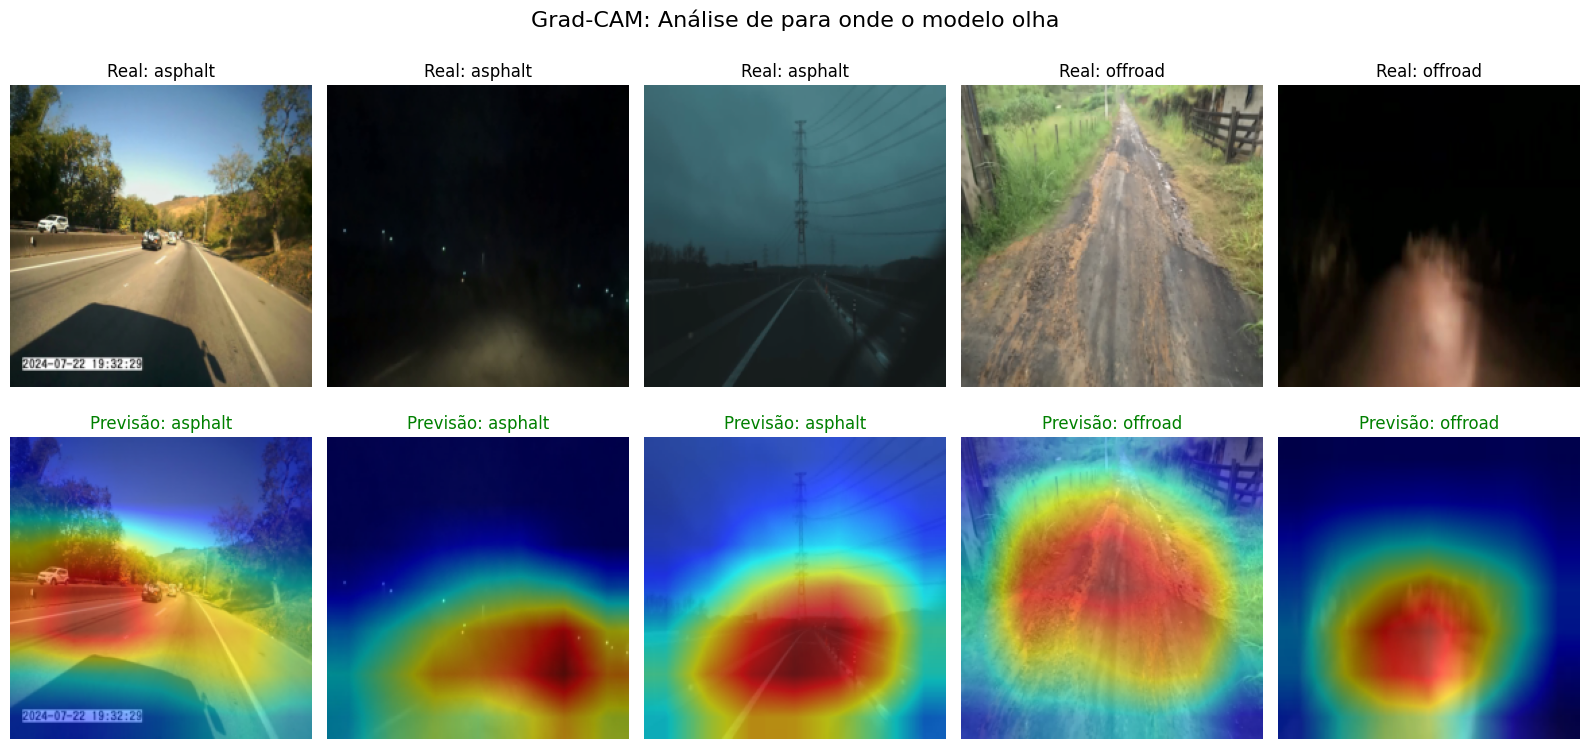

In [140]:
visualization_grad_cam(
    model=baseline_model,
    dataset_test=baseline_test_dataset,
    device=config['device'],
    title='Exp 1. Baseline'
)

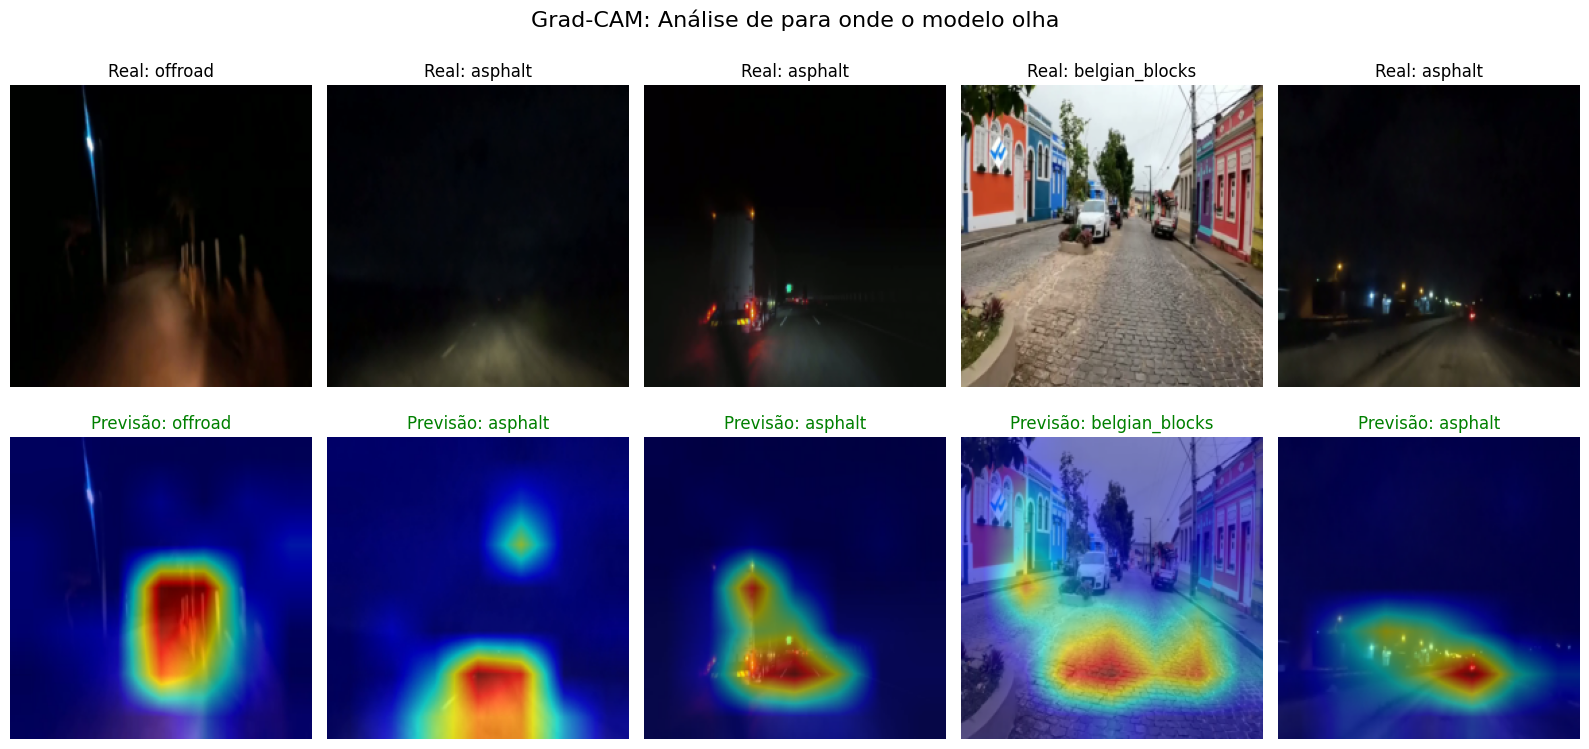

In [141]:
visualization_grad_cam(
    model=bse2_model,
    dataset_test=baseline_test_dataset,
    device=config['device'],
    title='Exp 2. Resnet50 com pesos'
)

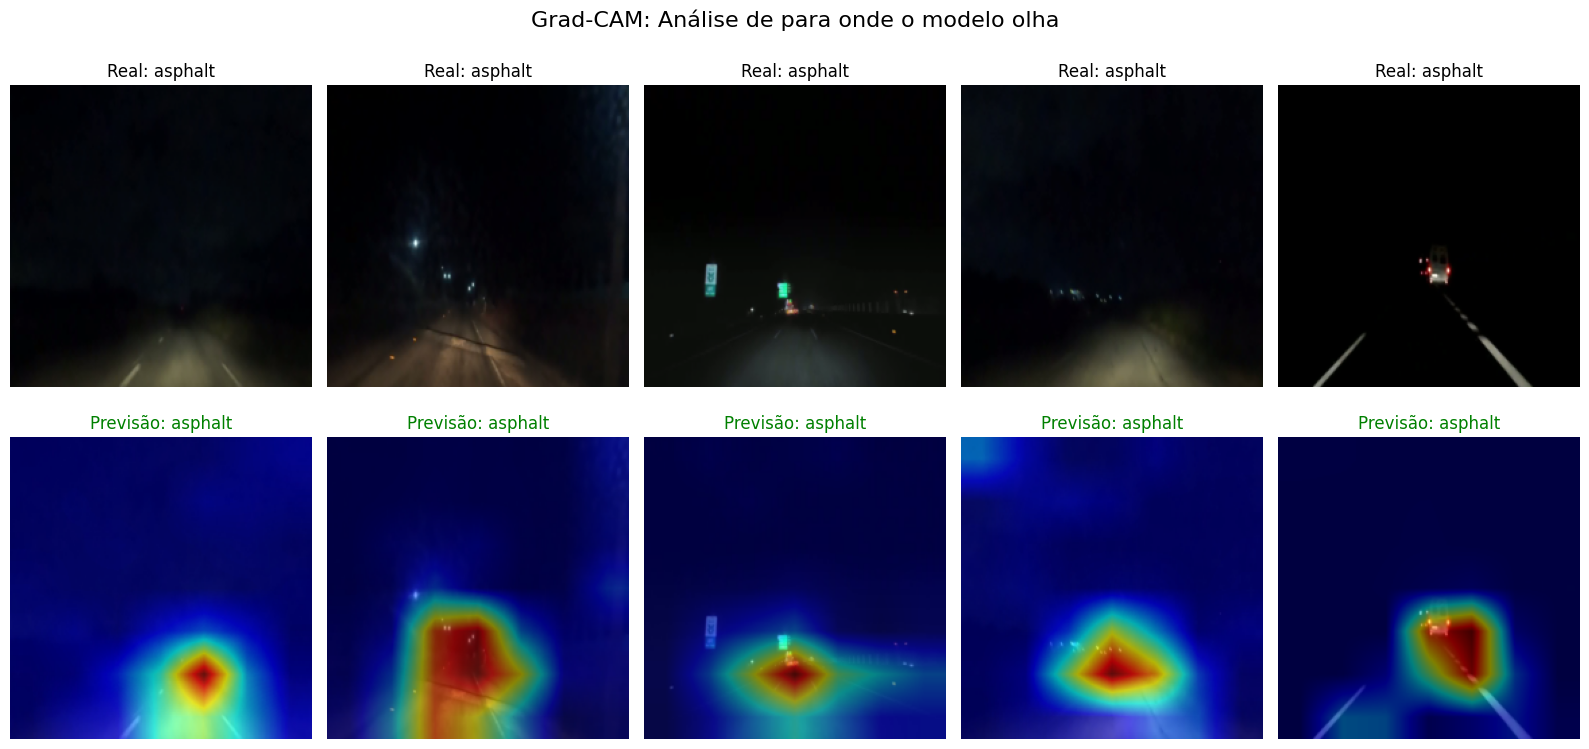

In [142]:
# Visualização do grad-cam para o experimento2
visualization_grad_cam(
    model=bline3_model,
    dataset_test=bline3_test,
    device=config['device'],
    title='Resnet50 + Augmentation + Peso'
)

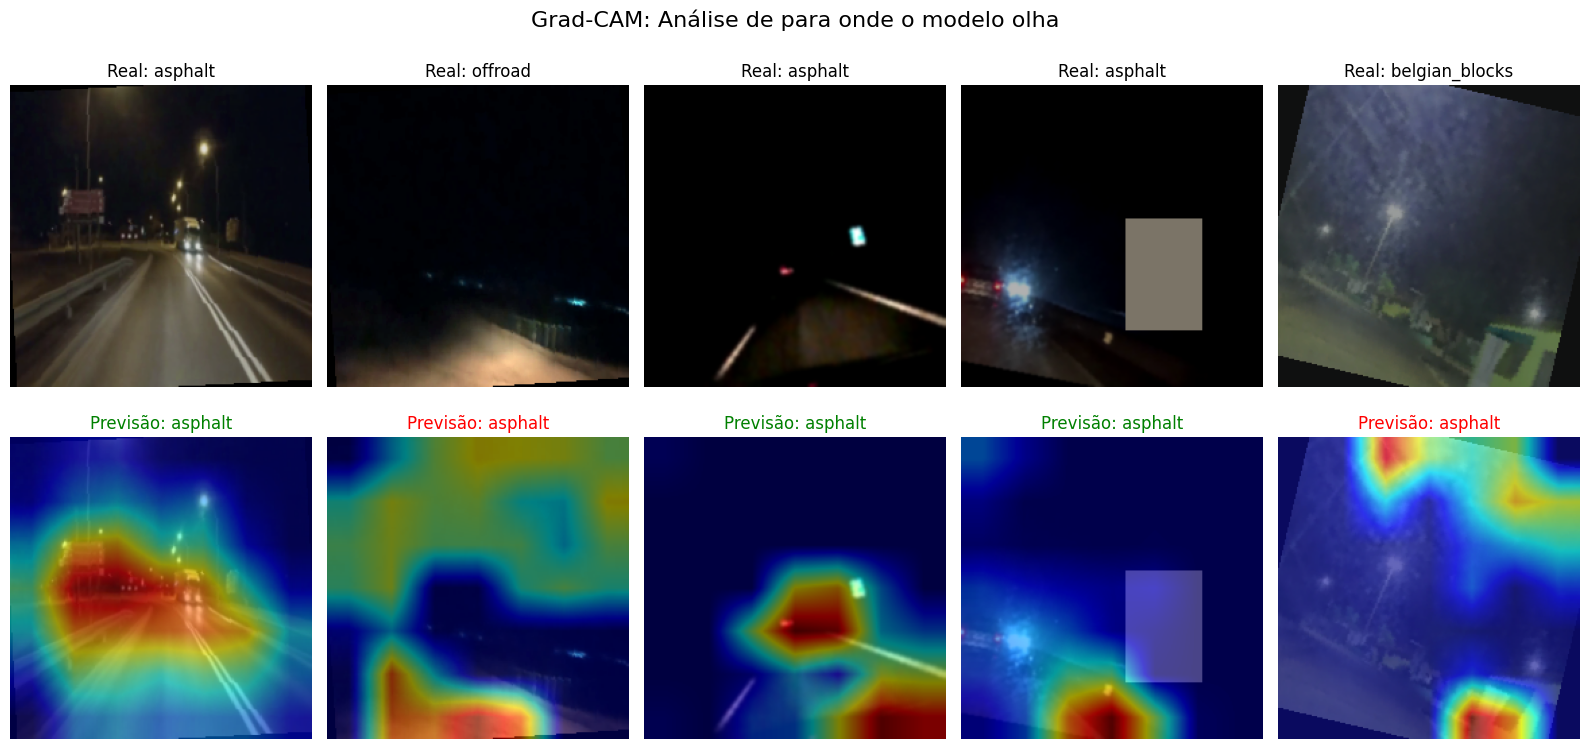

In [146]:
visualization_grad_cam(
    model=model_efficientnet,
    dataset_test=eff_test,
    device=config['device'],
    title='EfficientNet'
)

## **Análise Interpretativa — Grad-CAM:**

1. **Para `asphalt`**: a atenção está bem distribuída na textura da superfície

2. **Para `belgian_blocks`**: a atenção costuma estar nas **linhas de juntura** entre os blocos.

3. **Para `offroad`**: a atenção está na textura irregular do solo.

**Comparação entre experimentos**: os mapas do Exp.3 (com augmentation) mostram atenção mais focada e semanticamente correta do que o Exp.1 baseline e exp.2 com incrementação de pesos e exp.4 usando efficientnet, pois as augmentações geométricas forçam o modelo a não depender de features posicionais específicas.


<a id='11'></a>
# 11. Sumário comparativo dos experimentos

In [144]:
# ── Tabela Comparativa ───────────────────────────────────────────────────────
# Coleta os resultados de todos os experimentos para comparação direta

summary_data = {
    'Experimento': [
        'Exp.1 — ResNet-18 Baseline',
        'Exp.2 — ResNet-50 + Weighted Loss',
        'Exp.3 — ResNet-50 + Aug + Pesos',
        'Exp.4 — EfficientNet-B0',
    ],
    'F1-Macro': [
        results_baseline['f1_macro'],
        results_exp2['f1_macro'],
        results_exp3['f1_macro'],
        results_exp4['f1_macro'],
    ],
    'Balanced Acc.': [
        results_baseline['balanced_acc'],
        results_exp2['balanced_acc'],
        results_exp3['balanced_acc'],
        results_exp4['balanced_acc'],
    ],
    'F1 asphalt': [
        results_baseline['report']['asphalt']['f1-score'],
        results_exp2['report']['asphalt']['f1-score'],
        results_exp3['report']['asphalt']['f1-score'],
        results_exp4['report']['asphalt']['f1-score'],
    ],
    'F1 belgian_blocks': [
        results_baseline['report']['belgian_blocks']['f1-score'],
        results_exp2['report']['belgian_blocks']['f1-score'],
        results_exp3['report']['belgian_blocks']['f1-score'],
        results_exp4['report']['belgian_blocks']['f1-score'],
    ],
    'F1 offroad': [
        results_baseline['report']['offroad']['f1-score'],
        results_exp2['report']['offroad']['f1-score'],
        results_exp3['report']['offroad']['f1-score'],
        results_exp4['report']['offroad']['f1-score'],
    ],
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.set_index('Experimento')

# Destacar o melhor valor em cada coluna
print("\n" + "="*80)
print("  SUMÁRIO COMPARATIVO DOS EXPERIMENTOS")
print("="*80)
print(df_summary.round(3).to_string())
print()

# Identificar o melhor experimento
best_exp = df_summary['F1-Macro'].idxmax()
best_f1  = df_summary['F1-Macro'].max()
print(f"✅ Melhor experimento por F1-Macro: {best_exp}")
print(f"   F1-Macro = {best_f1:.3f}")



  SUMÁRIO COMPARATIVO DOS EXPERIMENTOS
                                   F1-Macro  Balanced Acc.  F1 asphalt  F1 belgian_blocks  F1 offroad
Experimento                                                                                          
Exp.1 — ResNet-18 Baseline            0.832          0.792       0.965              0.609       0.922
Exp.2 — ResNet-50 + Weighted Loss     0.851          0.826       0.961              0.769       0.822
Exp.3 — ResNet-50 + Aug + Pesos       0.875          0.850       0.959              0.821       0.843
Exp.4 — EfficientNet-B0               0.646          0.658       0.869              0.419       0.651

✅ Melhor experimento por F1-Macro: Exp.3 — ResNet-50 + Aug + Pesos
   F1-Macro = 0.875


## Análise Comparativa de Todos os Experimentos

Ao longo deste notebook colab, foi conduzida uma série de quatro experimentos iterativos com o objetivo de otimizar a classificação das 3 classes `asphalt`, `belgian_blocks` e `offroad`. O foco principal foi lidar com a **limitação** e consequentemente o desbalanceamento da quantidade de imagens por classe e melhorar a capacidade de generalização do modelo, especialmente para a classe mais complicada de se trabalhar (belgian_blocks).

Segue abaixo a análise da evolução técnica e os resultados obtidos:

1. Baseline (Exp. 1 – ResNet-18 Baseline):
O baseline apresentou um bom desempenho geral (F1-Macro de 0.832), mas revelou um viés nitidamente percebido. A classe asphalt obteve um F1-Score excelente (0.965), porém o modelo **falhou** severamente na classe `belgian_blocks` (0.609). Isso indicou que a rede estava priorizando a classe `Asphalt`, um comportamento típico de datasets desbalanceados, uma vez que sem a adição de pesos, valia mais a pena para o modelo chutar que a classe era Asphalt ao invés de belgian_blocks.

2. Adição de pesos para diminuir o desbalanceamento: (Exp. 2 – ResNet-50 + Weighted Loss):
Ao aumentar a capacidade da rede para uma ResNet-50 e introduzir pesos na função de perda (Weighted Cross-Entropy Loss), os erros nas classes minoritárias foram penaliazdos. O resultado foi percebido de imediato: o F1-Score da classe belgian_blocks saltou de 0.609 para 0.769. Houve um sacrifício na classe offroad (de 0.922 para 0.822), mas a `Acurácia Balanceada` geral subiu, provando que, no geral, o modelo se tornou mais robusto.

3. O Melhor Cenário e o melhor a ser utilizado (Exp. 3 – ResNet-50 + Augmentation + Pesos):
Combinou-se os pesos na função de custo com técnicas de Data Augmentation. Esta sinergia reduziu o overfitting e forçou o modelo a aprender invariâncias nas imagens. Este experimento foi declarado, por mim, como o vencedor, atingindo o maior F1-Macro (0.875) e elevando o desempenho da classe belgian_blocks para o seu ápice (0.821), o que é bem impressionante.

4. O Modelo EfficientNet-B0 (Exp. 4 – EfficientNet-B0):
Apesar de ser uma arquitetura moderna e eficiente, o Experimento 4 obteve o pior desempenho (F1-Macro de 0.646). Como texturas de asfalto e paralelepípedos são específicas e muito diferentes do domínio original do ImageNet, a falta de um fine-tuning mais bem elaborado nas camadas convolucionais impediu a adaptação ao nosso problema. Infelizmente, esse problema foi observado, mas não houve tempo hábil para resolvê-lo.

**Veredito Final**:
O Experimento 3 (ResNet-50 + Augmentation + Weighted Loss) é o modelo definitivo escolhido para este problema. Ele demonstrou que a combinação de uma arquitetura profunda com estratégias de compensação de dados (aumento artificial e penalização matemática) é o caminho ideal para lidar com a complexidade e o desbalanceamento das imagens de pavimentos urbanos e off-road.

<a id='12'></a>
## 12. Teste de robustez com múltiplas seeds

> **Problema**: Nesse dataset pequeno só existem 880 imagens para treino, logo a variância entre runs é alta. O mesmo modelo com seed diferente pode obter F1-Macro 5–10pp diferente.
>
> **Solução** - **Multi-seed**: treina o melhor modelo com 3 seeds para estimar variância real dos resultados



In [149]:
# Multi-seed: Exp.3 com 3 seeds diferentes
multi_seed_results = []

for seed_val in config['multi_seeds']:
    print(f"\n{'─'*45}  seed={seed_val}  {'─'*45}")
    all_seeds(seed_val)

    # criação do modelo do resnet para testar // ms = multiseed:

    model_ms_train = ImageFolder(root=root_train, transform=train_transforms)
    model_ms_test =  ImageFolder(root=root_test, transform=val_test_transforms)

    model_ms_train_loader = DataLoader(model_ms_train,
                                    batch_size= config['batch_size'],
                                    shuffle=True,
                                    num_workers=config['num_workers'])

    model_ms_test_loader = DataLoader(model_ms_test,
                                    batch_size=config['batch_size'],
                                    shuffle=False,
                                    num_workers=config['num_workers'])

    # Criação do modelo de treino 3
    model_ms_exp = resnet50(weights=ResNet50_Weights.DEFAULT)

    for nome, param in model_ms_exp.named_parameters():
      if 'layer4' in nome or 'fc' in nome:
        param.requires_grad = True
      else:
        param.requires_grad = False

    model_ms_features = model_ms_exp.fc.in_features

    model_ms_exp.fc = nn.Sequential(nn.Linear(model_ms_features, 512),
                                  nn.BatchNorm1d(512),
                                  nn.ReLU(),
                                  nn.Dropout(0.3),
                                  nn.Linear(512, len(config['classes'])))

    modelo_ms = model_ms_exp.to(device)

    # Loss, optimizer e scheduler
    loss_ms = nn.CrossEntropyLoss(weight=global_weights)
    opt_ms = optim.Adam(filter(lambda p: p.requires_grad, modelo_ms.parameters()),
                        lr=config['learning_rate'], weight_decay=config['weight_decay'])
    sch_ms = optim.lr_scheduler.ReduceLROnPlateau(opt_ms, mode='min', patience=config['patience_lr'])

    hist_ms = model_train(modelo_ms, model_ms_train_loader, model_ms_test_loader, loss_ms,
                          opt_ms, sch_ms, epochs=15, device=device,
                          save_path=f'modelomultiseed_seed{seed_val}.pth',
                          experiment_name=f'Multi-seed seed={seed_val}')
    modelo_ms.load_state_dict(torch.load(f'modelomultiseed_seed{seed_val}.pth'))
    modelo_ms.eval()

    all_targets, all_predictions = [], []
    with torch.no_grad():
        for imgs, lbls in model_ms_test_loader:
            # Corrected: Call the model, not the dataloader, for predictions
            _, preds = torch.max(modelo_ms(imgs.to(device)), 1)
            all_targets.extend(lbls.numpy()); all_predictions.extend(preds.cpu().numpy())

    rep = classification_report(all_targets, all_predictions, target_names=config['classes'],
                                output_dict=True, zero_division=0)
    multi_seed_results.append({
        'seed': seed_val,
        'f1_macro': f1_score(all_targets, all_predictions, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(all_targets, all_predictions),
        'f1_asphalt': rep['asphalt']['f1-score'],
        'f1_belgian': rep['belgian_blocks']['f1-score'],
        'f1_offroad': rep['offroad']['f1-score'],
    })
    print(f"seed={seed_val} → F1-Macro={multi_seed_results[-1]['f1_macro']:.3f} | "
          f"BalAcc={multi_seed_results[-1]['balanced_acc']:.3f}")

dataframe_multiseed = pd.DataFrame(multi_seed_results).set_index('seed')
print("\n" + "="*55)
print("  Resultados Multi-Seed — Exp.3")
print("="*55)
print(dataframe_multiseed.round(3).to_string())
print("\nMédia ± Desvio Padrão:")
for col in dataframe_multiseed.columns:
    print(f"  {col:<20}: {dataframe_multiseed[col].mean():.3f} ± {dataframe_multiseed[col].std():.3f}")


─────────────────────────────────────────────  seed=42  ─────────────────────────────────────────────
Início do treino Multi-seed seed=42




100%|██████████| 28/28 [00:24<00:00,  1.16it/s]


Ép 01/15 | Loss Treino: 0.6470 | Loss Teste: 0.7578 | Acc Teste: 0.720 | F1-Macro: 0.582
 Novo melhor modelo em 'modelomultiseed_seed42.pth' (loss=0.7578)


100%|██████████| 28/28 [00:32<00:00,  1.16s/it]


Ép 02/15 | Loss Treino: 0.2638 | Loss Teste: 0.6204 | Acc Teste: 0.783 | F1-Macro: 0.659
 Novo melhor modelo em 'modelomultiseed_seed42.pth' (loss=0.6204)


...

Ép 13/15 | Loss Treino: 0.0371 | Loss Teste: 0.2796 | Acc Teste: 0.917 | F1-Macro: 0.839


100%|██████████| 28/28 [00:24<00:00,  1.14it/s]


Ép 14/15 | Loss Treino: 0.0365 | Loss Teste: 0.2406 | Acc Teste: 0.913 | F1-Macro: 0.832


100%|██████████| 28/28 [00:25<00:00,  1.09it/s]


Ép 15/15 | Loss Treino: 0.0284 | Loss Teste: 0.2788 | Acc Teste: 0.910 | F1-Macro: 0.812
Treinamento concluído. Melhor loss de teste: 0.2235

seed=2026 → F1-Macro=0.847 | BalAcc=0.804

  Resultados Multi-Seed — Exp.3
      f1_macro  balanced_acc  f1_asphalt  f1_belgian  f1_offroad
seed                                                            
42       0.860         0.860       0.956       0.800       0.822
7        0.857         0.845       0.957       0.764       0.852
2026     0.847         0.804       0.953       0.755       0.833

Média ± Desvio Padrão:
  f1_macro            : 0.855 ± 0.007
  balanced_acc        : 0.836 ± 0.029
  f1_asphalt          : 0.955 ± 0.002
  f1_belgian          : 0.773 ± 0.024
  f1_offroad          : 0.836 ± 0.015


###`Avaliação rápida das múltiplas sementes`:

- O uso de múltiplas sementes (42, 7, 2026) mostra que o modelo é muito estável.

- F1-Macro médio: 0.855±0.007. Um desvio padrão tão baixo (apenas 0.007) indica que o resultado não é "sorte" de uma inicialização específica, mas sim que o modelo aprendeu padrões reais e reprodutíveis.

- O maior problema dentro das métricas está em volta das classes belgian_blocks e offroads, mas isso é o esperado. Ambas as classes têm poucas imagens em comparação a classe asphalt e portanto, seria necessário fazer um data augmentation mais agressivo ou ter mais imagens de ambas as classes.

<a id='13'></a>

------
# 13. Conclusão final e o que poderia ser feito com mais tempo:

Esse colab demonstrou que o problema de classificação de superfícies de vias é possível de ser solucionado com transfer learning, desde que as intervenções sejam guiadas pela análise dos dados.
------

### 🛠️ Contribuições Principais

As intervenções realizadas neste trabalho podem ser resumidas em três pilares:

  - Diagnóstico Analítico: Identificação quantitativa do desbalanceamento crítico (6.8x), das distorções geométricas na redimensionamento (16:9 para 1:1) e da correlação espúria entre luminosidade e classe antes de qualquer etapa de modelagem.  

  - Intervenções Baseadas em Evidências: Cada modificação no pipeline — como o uso de Weighted Loss, Data Augmentation estratégica e o WeightedRandomSampler — foi uma resposta direta às observações da EDA, testadas de forma isolada para garantir a atribuição correta de ganho de performance.  

  - Avaliação Multidimensional: A robustez do modelo foi validada além da acurácia simples, utilizando F1-Macro, Matrizes de Confusão e Grad-CAM para interpretabilidade

-------
### 📈 Limitações e O que poderia ser feito com mais tempo

A principal lacuna para uma solução em nível de produção é a escassez de dados, especialmente de classes minoritárias em condições climáticas ou de iluminação adversas. Com um dataset de treino com somente 880 imagens e um dataset de teste com 300 imagens bastante desbalanceadas, o teto de performance é limitado.  

Caso houvesse mais tempo e recursos, os possíveis próximos passos seriam:

  - Aquisição de Dados Direcionada: Focar na coleta de amostras de "Off-road" e "Belgian Blocks" em cenários noturnos e de chuva.

  - Active Learning: Implementar um ciclo de aprendizado ativo para identificar e rotular imagens onde o modelo apresenta baixa confiança (incerteza epistêmica).

  - Data Augmentation Sintética: Explorar o uso de GANs ou Diffusion Models para gerar variações sintéticas controladas das classes menos representadas.
------

### 📂 Acesso aos Artefatos

Todos os modelos treinados (arquivos .pth), logs de experimentos e resultados detalhados estão disponíveis no link abaixo:

> 🔗 [**Repositório de Artefatos - Google Drive**](https://drive.google.com/drive/folders/18AhBoIY2eM8fxzpCSCAbYgrWVjmM_mac?usp=sharing)
-----

### 🤖 Transparência e Uso de Ferramentas de Apoio

`Gemini modo Raciocínio`: Foi usado majoritariamente para discussão de ideias, melhorias de prompts para serem utilizados no claude para diminuir o consumo de tokens, revisão técnica no notebook e correção em comentários feitos no colab.

`Claude Sonnet 4.6(Versão Gratuita)`: Focado em Code Review, sugestões de refatoração do código e avaliação crítica do notebook baseada nos critérios metodológicos citados abaixo:

- 1.1 Justificativa Metodológica (0 – 15 pts)

- 1.2 Análise Crítica dos Resultados (0 – 15 pts)

- 1.3 Interpretabilidade da Solução (0 – 10 pts)

- 2.1 Reprodutibilidade (0 – 10 pts)

- 2.2 Organização e Qualidade do Código (0 – 15 pts)

- 2.3 Pipeline de Dados e Atributos (0 – 10 pts)

- 3.1 Capacidade de Generalização (0 – 15 pts)

- 3.2 Robustez Experimental (0 – 10 pts)

`Kaggle:` foi utilizado para buscar conjuntos de dados parecidos que refletem problemas de classificação com deep learning. Não achei nenhum igual, mas consegui algumas boas ideias para implementação de códigos que resolviam problemas com a mesma ideia.

--------

Esse projeto levou bastante tempo, testei MUITO mais coisas do que está presente nesse notebook e MUITAS coisas foram apagadas, que possivelmente podem ser vistas no histórico de revisões do notebook, sendo assim o resultado de um processo que envolveu diversos testes e refatorações.

Agradeço pela oportunidade de ter participado do desafio, e desejo um bom dia, boa tarde ou boa noite para você que avaliou esse colab!